# Data formatting

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import cvxpy as cp
import seaborn as sns
import matplotlib

from sklearn.linear_model import LinearRegression
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import (check_X_y, check_array,check_is_fitted)
from statsmodels.tsa.arima_process import ArmaProcess
from google.colab import files
from google.colab import drive
drive.mount('/mnt/drive', force_remount=True)
from matplotlib import pyplot as plt
from cycler import cycler

Mounted at /mnt/drive


In [ ]:
df_1 = (pd.read_csv("/mnt/drive/MyDrive/Colab_data/df_ct_filtered.csv")).rename(columns={"FIPS5": "FIPS"})
df_2 = (pd.read_csv("/mnt/drive/MyDrive/Colab_data/df_zip_filtered.csv"))
df_2['state'] = df_2['FIPS'].astype(str).str[0:2]
geo_city_df = pd.concat([df_1[['GEOID', 'city']], df_2[['GEOID', 'city']]]).drop_duplicates()

df_dis =pd.read_csv("/mnt/drive/MyDrive/Colab_data/Disaster.csv")

In [ ]:
df_1 = df_1[np.isfinite(df_1['filings_2020_p2'])]
df_2 = df_2[np.isfinite(df_2['filings_2020_p2'])]

In [ ]:
# Get record from FEMA API
url = "https://www.fema.gov/api/open/v2/DisasterDeclarationsSummaries?$format=csv&$allrecords=true"

# Make it to dataframe
dec = pd.read_csv(url)

# Make FIPS code
dec['fipsStateCode'] = dec['fipsStateCode'].astype(str).str.zfill(2)
dec['fipsCountyCode'] = dec['fipsCountyCode'].astype(str).str.zfill(3)
dec['FIPS'] = dec['fipsStateCode'] + dec['fipsCountyCode']
dec['FIPS'] = dec['FIPS'].astype(str).copy()

# Get a simpler dec
dec = dec[['disasterNumber', 'state', 'designatedArea', 'fipsStateCode', 'fipsCountyCode', 'FIPS']].copy()
dec = pd.merge(dec, df_dis, left_on='disasterNumber', right_on='Num', how='left').copy()
dec = dec.dropna(subset=["month_num"]).copy()

disaster_list = dec["disasterNumber"].unique().astype(str)

In [ ]:
sc_ct =pd.read_csv("/mnt/drive/MyDrive/Colab_data/SC_ct.csv")
sc_ct['GEOID'] = sc_ct['TRACT'].astype(str).str.zfill(11).str.replace(r"\.0$", "", regex=True)
HD_ct =pd.read_csv("/mnt/drive/MyDrive/Colab_data/HD_ct.csv")
HD_ct = HD_ct.dropna(subset=['TRACT']).copy()
HD_ct['GEOID'] = HD_ct['TRACT'].astype(int).astype(str).str.zfill(11)
acs_ct =pd.read_csv("/mnt/drive/MyDrive/Colab_data/acs_ct.csv")
acs_ct['GEOID'] = acs_ct['GEOID'].astype(str).copy()

# Census Tract level

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
import matplotlib.cm as cm
from matplotlib.lines import Line2D

In [ ]:
# -----------------------------------
# Synthetic Control Class
# -----------------------------------
class SyntheticControl(BaseEstimator, RegressorMixin):
    def __init__(self):
        pass

    def fit(self, y_pre_co, y_pre_tr):
        y_pre_co, y_pre_tr = check_X_y(y_pre_co, y_pre_tr)
        w = cp.Variable(y_pre_co.shape[1])
        objective = cp.Minimize(cp.sum_squares(y_pre_co @ w - y_pre_tr))
        constraints = [cp.sum(w) == 1, w >= 0]
        prob = cp.Problem(objective, constraints)
        self.loss_ = prob.solve(verbose=False)
        self.w_ = w.value
        self.is_fitted_ = True
        return self

    def predict(self, y_co):
        check_is_fitted(self)
        y_co = check_array(y_co)
        return y_co @ self.w_

# -----------------------------------
# reshape function
# -----------------------------------
def reshape_sc_data(df, geo_col, time_col, y_col, tr_geos, tr_start):
    df_piv = df.pivot_table(values=y_col, index=time_col, columns=geo_col)
    y_co = df_piv.drop(columns=tr_geos)
    y_tr = df_piv[tr_geos]
    y_pre_co = y_co[df_piv.index < tr_start]
    y_pre_tr = y_tr[df_piv.index < tr_start]
    y_post_co = y_co[df_piv.index >= tr_start]
    y_post_tr = y_tr[df_piv.index >= tr_start]
    return y_pre_co, y_pre_tr, y_post_co, y_post_tr


=== Processing Disaster 4766 ===
144
144
0
No control GEOIDs available for disaster 4766, skipping...

=== Processing Disaster 4760 ===
0
No treatment GEOIDs available for disaster 4760, skipping...

=== Processing Disaster 4759 ===
0
No treatment GEOIDs available for disaster 4759, skipping...

=== Processing Disaster 4752 ===
0
No treatment GEOIDs available for disaster 4752, skipping...

=== Processing Disaster 4745 ===
0
No treatment GEOIDs available for disaster 4745, skipping...

=== Processing Disaster 4739 ===
0
No treatment GEOIDs available for disaster 4739, skipping...

=== Processing Disaster 4735 ===
242
413
171
--- GEOID 47157000100 completed ---
--- GEOID 47157000200 completed ---
--- GEOID 47157000300 completed ---
--- GEOID 47157000400 completed ---
--- GEOID 47157000600 completed ---
--- GEOID 47157000700 completed ---
--- GEOID 47157000800 completed ---
--- GEOID 47157000900 completed ---
--- GEOID 47157001100 completed ---
--- GEOID 47157001200 completed ---
--- GE

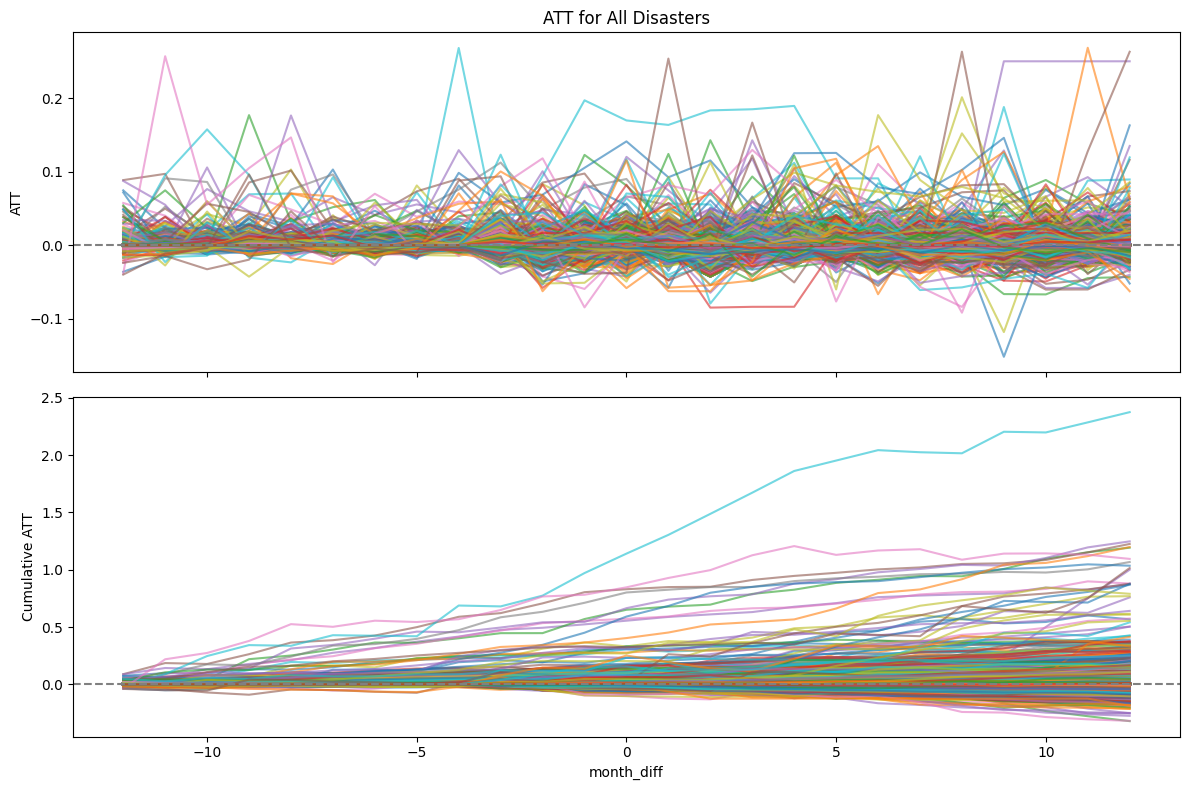

In [ ]:
disaster_list = dec["disasterNumber"].unique().astype(str)
df_1['state'] = df_1['state'].astype(str)

# Dictionary
att_all = {}
cum_att_all = {}

for disaster_id in disaster_list:
    print(f"\n=== Processing Disaster {disaster_id} ===")

    # --- FIPS & Treatment GEOIDs ---
    fips = dec.loc[dec["disasterNumber"].astype(str) == disaster_id, "FIPS"].unique()
    treat_geoids = df_1.loc[df_1["GEOID"].astype(str).str[:5].isin(fips), "GEOID"].unique()
    print(len(treat_geoids))
    if len(treat_geoids) == 0:
      print(f"No treatment GEOIDs available for disaster {disaster_id}, skipping...")
      continue
    impact_month = int(dec.loc[dec["disasterNumber"].astype(str) == disaster_id, "month_num"].unique()[0])

    # --- df_state & Control GEOIDs ---
    state_code = str(treat_geoids[0])[:2]
    df_state = df_1[df_1["state"] == state_code].copy()
    print(len(df_state["GEOID"].unique()))
    control_geoids = df_state.loc[~df_state["GEOID"].isin(treat_geoids), "GEOID"].unique()
    print(len(control_geoids))
   # Skip if there are no controls
    if len(control_geoids) == 0:
        print(f"No control GEOIDs available for disaster {disaster_id}, skipping...")
        continue

    # --- month_diff ---
    df_state["month_diff"] = df_state["month_num"] - impact_month
    df_trim = df_state[df_state["month_diff"].between(-12, 12)].copy()

    # --- Only complete GEOIDs---
    all_months = set(range(-12, 13))
    valid_geoids = [geo for geo in list(treat_geoids) + list(control_geoids)
                    if all_months.issubset(set(df_trim.loc[df_trim["GEOID"] == geo, "month_diff"]))]

    # --- Synthetic Control ---
    for geo in treat_geoids:
        if geo not in valid_geoids:
            print(f"Treatment GEOID {geo} does not have full months, skip")
            continue

        df_tr = df_trim[df_trim["GEOID"] == geo].copy()
        df_co = df_trim[df_trim["GEOID"].isin(valid_geoids) & df_trim["GEOID"].isin(control_geoids)].copy()

        df_sc = pd.concat([df_tr, df_co])

        y_pre_co, y_pre_tr, y_post_co, y_post_tr = reshape_sc_data(
            df_sc, geo_col="GEOID", time_col="month_diff", y_col="filings_2020_p2",
            tr_geos=[geo], tr_start=-3
        )

        model = SyntheticControl()
        model.fit(y_pre_co.values, y_pre_tr.mean(axis=1).values)

        y_co = pd.concat([y_pre_co, y_post_co])
        y_tr = pd.concat([y_pre_tr, y_post_tr])
        y_hat = model.predict(y_co.values)

        # --- Save ---
        key = f"{disaster_id}_{geo}"
        att_all[key] = y_tr.mean(axis=1) - y_hat
        cum_att_all[key] = att_all[key].cumsum()

        print(f"--- GEOID {geo} completed ---")

# --- Plot ---
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for key in att_all:
    axs[0].plot(att_all[key].index, att_all[key], alpha=0.6, label=key)
axs[0].axhline(0, color="gray", linestyle="--")
axs[0].set_ylabel("ATT")
axs[0].set_title("ATT for All Disasters")

for key in cum_att_all:
    axs[1].plot(cum_att_all[key].index, cum_att_all[key], alpha=0.6, label=key)
axs[1].axhline(0, color="gray", linestyle="--")
axs[1].set_xlabel("month_diff")
axs[1].set_ylabel("Cumulative ATT")

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# --- att_all -> DataFrame ---
att_list = []
for key, series in att_all.items():
    disaster_id, geo = key.split("_")
    df_tmp = pd.DataFrame({
        "disaster_id": disaster_id,
        "GEOID": geo,
        "month_diff": series.index,
        "ATT": series.values
    })
    att_list.append(df_tmp)

att_df = pd.concat(att_list, ignore_index=True)

# --- cum_att_all -> DataFrame ---
cum_att_list = []
for key, series in cum_att_all.items():
    disaster_id, geo = key.split("_")
    df_tmp = pd.DataFrame({
        "disaster_id": disaster_id,
        "GEOID": geo,
        "month_diff": series.index,
        "Cumulative_ATT": series.values
    })
    cum_att_list.append(df_tmp)

cum_att_df = pd.concat(cum_att_list, ignore_index=True)

# --- CSV ---
save_dir = "/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/"
att_df.to_csv(save_dir + "att_all_PL.csv", index=False)
cum_att_df.to_csv(save_dir + "cum_att_all_PL.csv", index=False)

print("Saved att_all_PL.csv and cum_att_all_PL.csv with GEOID and disaster_id columns.")

Saved att_all_PL.csv and cum_att_all_PL.csv with GEOID and disaster_id columns.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


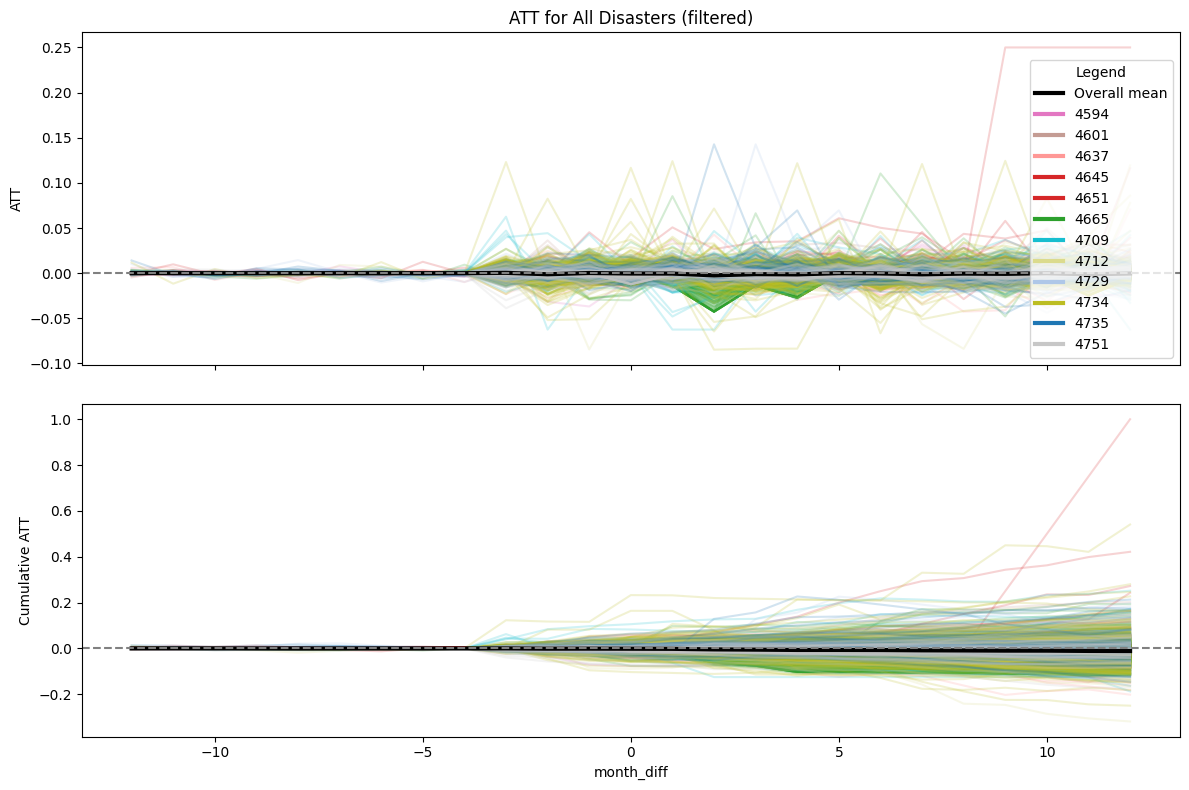

Filtered GEOIDs: ['47157000100', '47157000600', '47157000800', '47157001600', '47157001700', '47157001900', '47157002100', '47157002500', '47157002900', '47157003100', '47157003200', '47157003400', '47157003500', '47157003900', '47157004200', '47157004300', '47157005700', '47157006300', '47157006600', '47157007200', '47157007400', '47157007821', '47157008700', '47157008800', '47157009100', '47157009300', '47157009400', '47157009501', '47157009600', '47157010002', '47157010300', '47157010500', '47157010710', '47157011020', '47157011100', '47157011300', '47157020102', '47157020210', '47157020301', '47157020400', '47157020524', '47157020632', '47157020651', '47157020657', '47157020658', '47157020834', '47157020835', '47157020837', '47157020901', '47157021022', '47157021023', '47157021111', '47157021113', '47157021121', '47157021124', '47157021125', '47157021126', '47157021135', '47157021136', '47157021138', '47157021139', '47157021141', '47157021312', '47157021341', '47157021351', '471570

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

att_df = pd.read_csv("/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/att_all_PL.csv")
cum_att_df = pd.read_csv("/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/cum_att_all_PL.csv")

# --- att_all -> dict ---
att_all = {}
for (disaster_id, geo), group in att_df.groupby(["disaster_id", "GEOID"]):
    series = pd.Series(data=group["ATT"].values, index=group["month_diff"].values)
    key = f"{disaster_id}_{geo}"
    att_all[key] = series

# --- cum_att_all -> dict ---
cum_att_all = {}
for (disaster_id, geo), group in cum_att_df.groupby(["disaster_id", "GEOID"]):
    series = pd.Series(data=group["Cumulative_ATT"].values, index=group["month_diff"].values)
    key = f"{disaster_id}_{geo}"
    cum_att_all[key] = series


# --- Disaster list and colors ---
n_disasters = len(disaster_list)
cmap = plt.get_cmap('tab20')
colors = {disaster_list[i]: cmap(i / n_disasters) for i in range(n_disasters)}

# List to store GEOIDs that remain after filtering
filtered_geoids = []

# List to store all filtered ATT/Cumulative ATT series
all_att_series = []
all_cum_att_series = []

fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
legend_plots = {}

# --- value at t = -4 ---
cum_minus1 = []
for key, series in cum_att_all.items():
    if -4 in series.index:
        cum_minus1.append(series.loc[-4])

cum_minus1 = np.array(cum_minus1)

# --- IQR ---
Q1 = np.quantile(cum_minus1, 0.25)
Q3 = np.quantile(cum_minus1, 0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

filtered_geoids = []
all_att_series = []
all_cum_att_series = []
legend_plots = {}

for key, cum_series in cum_att_all.items():
    if -4 in cum_series.index:
        value_minus1 = cum_series.loc[-4]
        if lower <= value_minus1 <= upper:
            disaster_id, geo = key.split('_')
            color = colors.get(disaster_id, 'gray')

            # Plot individual GEOID lines
            axs[0].plot(att_all[key].index, att_all[key], alpha=0.2, color=color)
            axs[1].plot(cum_series.index, cum_series, alpha=0.2, color=color)

            # Add to filtered GEOID list
            filtered_geoids.append(geo)

            # Store for overall mean
            all_att_series.append(att_all[key])
            all_cum_att_series.append(cum_series)

            # For legend
            if disaster_id not in legend_plots:
                legend_plots[disaster_id] = color

# --- Compute overall mean (all disasters together) ---
if len(all_att_series) > 0:
    mean_att = np.mean([s.values for s in all_att_series], axis=0)
    mean_cum_att = np.mean([s.values for s in all_cum_att_series], axis=0)

    axs[0].plot(all_att_series[0].index, mean_att, color='black', linewidth=3, label='Overall mean')
    axs[1].plot(all_cum_att_series[0].index, mean_cum_att, color='black', linewidth=3, label='Overall mean')

# Add horizontal lines at zero
axs[0].axhline(0, color="gray", linestyle="--")
axs[0].set_ylabel("ATT")
axs[0].set_title("ATT for All Disasters (filtered)")

axs[1].axhline(0, color="gray", linestyle="--")
axs[1].set_xlabel("month_diff")
axs[1].set_ylabel("Cumulative ATT")

# Add legend for disasters and overall mean
for disaster_id, color in legend_plots.items():
    axs[0].plot([], [], color=color, label=disaster_id, linewidth=3)
    axs[1].plot([], [], color=color, label=disaster_id, linewidth=3)

axs[0].legend(title="Legend", fontsize=10)

plt.tight_layout()
plt.show()

print("Filtered GEOIDs:", filtered_geoids)

In [ ]:
# -------------------------------------------------
# IQR
# -------------------------------------------------
filtered_att_all = {}
filtered_cum_att_all = {}

for key, cum_series in cum_att_all.items():
    if -4 in cum_series.index:
        v = cum_series.loc[-4]
        if lower <= v <= upper:
            filtered_att_all[key] = att_all[key]
            filtered_cum_att_all[key] = cum_series

# -------------------------------------------------
# filtered_att_df
# -------------------------------------------------
filtered_att_df = pd.DataFrame(
    {key: series.values for key, series in filtered_att_all.items()}
)

# month_diff
filtered_att_df.insert(
    0,
    "month_diff",
    next(iter(filtered_att_all.values())).index
)

# -------------------------------------------------
# filtered_cum_att_df
# -------------------------------------------------
filtered_cum_att_df = pd.DataFrame(
    {key: series.values for key, series in filtered_cum_att_all.items()}
)

filtered_cum_att_df.insert(
    0,
    "month_diff",
    next(iter(filtered_cum_att_all.values())).index
)

save_dir = "/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/"

filtered_att_df.to_csv(
    save_dir + "filtered_att_all_PL.csv",
    index=False
)

filtered_cum_att_df.to_csv(
    save_dir + "filtered_cum_att_all_PL.csv",
    index=False
)

print("Saved filtered_att_all_PL.csv and filtered_cum_att_all_PL.csv")


Saved filtered_att_all_PL.csv and filtered_cum_att_all_PL.csv


# Zip level

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
import matplotlib.cm as cm
from matplotlib.lines import Line2D

In [ ]:
# -----------------------------------
# Synthetic Control Class
# -----------------------------------
class SyntheticControl(BaseEstimator, RegressorMixin):
    def __init__(self):
        pass

    def fit(self, y_pre_co, y_pre_tr):
        y_pre_co, y_pre_tr = check_X_y(y_pre_co, y_pre_tr)
        w = cp.Variable(y_pre_co.shape[1])
        objective = cp.Minimize(cp.sum_squares(y_pre_co @ w - y_pre_tr))
        constraints = [cp.sum(w) == 1, w >= 0]
        prob = cp.Problem(objective, constraints)
        self.loss_ = prob.solve(verbose=False)
        self.w_ = w.value
        self.is_fitted_ = True
        return self

    def predict(self, y_co):
        check_is_fitted(self)
        y_co = check_array(y_co)
        return y_co @ self.w_

# -----------------------------------
# reshape function
# -----------------------------------
def reshape_sc_data(df, geo_col, time_col, y_col, tr_geos, tr_start):
    df_piv = df.pivot_table(values=y_col, index=time_col, columns=geo_col)
    y_co = df_piv.drop(columns=tr_geos)
    y_tr = df_piv[tr_geos]
    y_pre_co = y_co[df_piv.index < tr_start]
    y_pre_tr = y_tr[df_piv.index < tr_start]
    y_post_co = y_co[df_piv.index >= tr_start]
    y_post_tr = y_tr[df_piv.index >= tr_start]
    return y_pre_co, y_pre_tr, y_post_co, y_post_tr


=== Processing Disaster 4766 ===
0
No treatment GEOIDs available for disaster 4766, skipping...

=== Processing Disaster 4760 ===
0
No treatment GEOIDs available for disaster 4760, skipping...

=== Processing Disaster 4759 ===
0
No treatment GEOIDs available for disaster 4759, skipping...

=== Processing Disaster 4752 ===
0
No treatment GEOIDs available for disaster 4752, skipping...

=== Processing Disaster 4745 ===
0
No treatment GEOIDs available for disaster 4745, skipping...

=== Processing Disaster 4739 ===
0
No treatment GEOIDs available for disaster 4739, skipping...

=== Processing Disaster 4735 ===
0
No treatment GEOIDs available for disaster 4735, skipping...

=== Processing Disaster 4732 ===
0
No treatment GEOIDs available for disaster 4732, skipping...

=== Processing Disaster 4730 ===
0
No treatment GEOIDs available for disaster 4730, skipping...

=== Processing Disaster 4729 ===
0
No treatment GEOIDs available for disaster 4729, skipping...

=== Processing Disaster 4726 

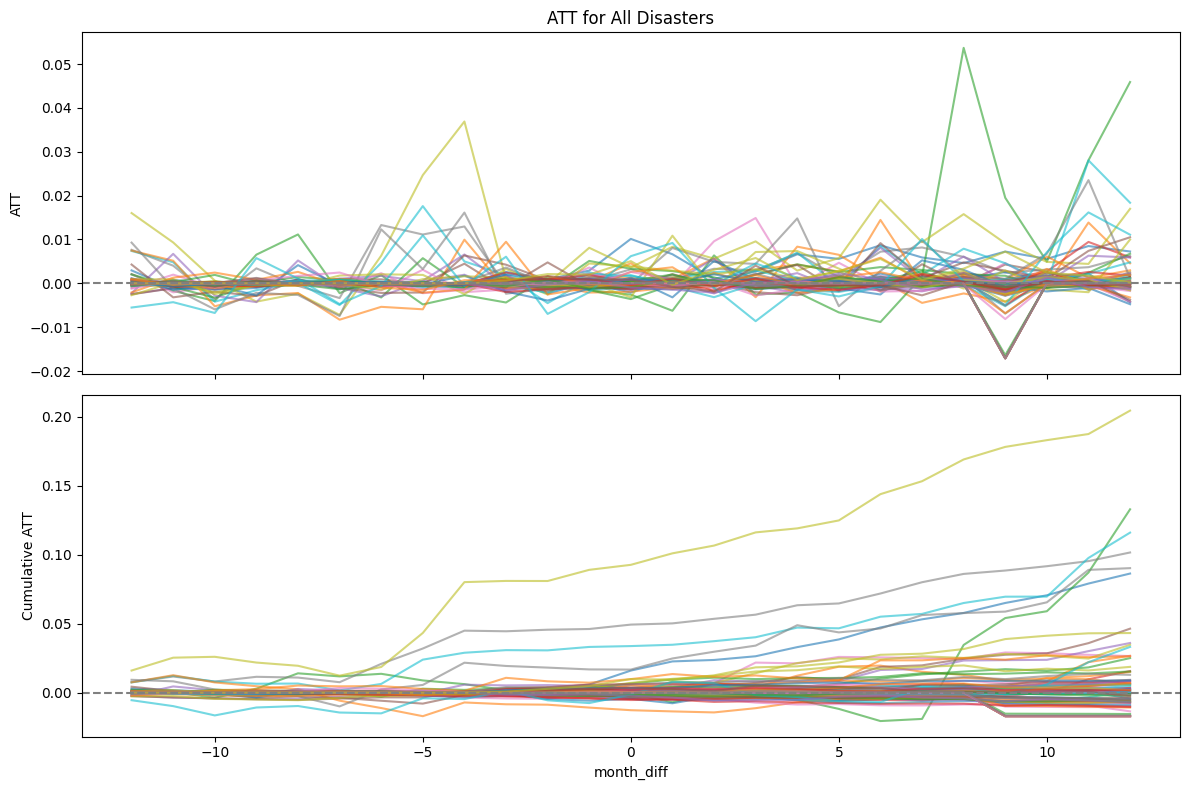

In [ ]:
disaster_list = dec["disasterNumber"].unique().astype(str)
df_2['state'] = df_2['state'].astype(str)

# Dictionary
att_all = {}
cum_att_all = {}

for disaster_id in disaster_list:
    print(f"\n=== Processing Disaster {disaster_id} ===")

    # --- FIPS & Treatment GEOIDs ---
    fips = dec.loc[dec["disasterNumber"].astype(str) == disaster_id, "FIPS"].unique()
    treat_geoids = df_2.loc[df_2["FIPS"].astype(str).str[:5].isin(fips), "GEOID"].unique()
    print(len(treat_geoids))
    if len(treat_geoids) == 0:
      print(f"No treatment GEOIDs available for disaster {disaster_id}, skipping...")
      continue
    impact_month = int(dec.loc[dec["disasterNumber"].astype(str) == disaster_id, "month_num"].unique()[0])
    print(impact_month)

    # --- df_state & Control GEOIDs ---
    state_code = str(fips[0])[:2]
    df_state = df_2[df_2["state"] == state_code].copy()
    print(len(df_state["GEOID"].unique()))
    control_geoids = df_state.loc[~df_state["GEOID"].isin(treat_geoids), "GEOID"].unique()
    print(len(control_geoids))
   # Skip if there are no controls
    if len(control_geoids) == 0:
        print(f"No control GEOIDs available for disaster {disaster_id}, skipping...")
        continue

    # --- month_diff ---
    df_state["month_diff"] = df_state["month_num"] - impact_month
    df_trim = df_state[df_state["month_diff"].between(-12, 12)].copy()

    # --- Only complete GEOIDs---
    all_months = set(range(-12, 13))
    valid_geoids = [geo for geo in list(treat_geoids) + list(control_geoids)
                    if all_months.issubset(set(df_trim.loc[df_trim["GEOID"] == geo, "month_diff"]))]

    # --- Synthetic Control ---
    for geo in treat_geoids:
        if geo not in valid_geoids:
            print(f"Treatment GEOID {geo} does not have full months, skip")
            continue

        df_tr = df_trim[df_trim["GEOID"] == geo].copy()
        df_co = df_trim[df_trim["GEOID"].isin(valid_geoids) & df_trim["GEOID"].isin(control_geoids)].copy()
        df_sc = pd.concat([df_tr, df_co])

        y_pre_co, y_pre_tr, y_post_co, y_post_tr = reshape_sc_data(
            df_sc, geo_col="GEOID", time_col="month_diff", y_col="filings_2020_p2",
            tr_geos=[geo], tr_start=-3
        )

        if y_pre_co.isna().any().any() or y_pre_tr.isna().any().any():
            print(f"Treatment GEOID {geo} or controls have NaN, skip")
            continue

        # --- Synthetic Control ---
        model = SyntheticControl()
        model.fit(y_pre_co.values, y_pre_tr.mean(axis=1).values)

        y_co = pd.concat([y_pre_co, y_post_co])
        y_tr = pd.concat([y_pre_tr, y_post_tr])
        y_hat = model.predict(y_co.values)

        # --- Save ---
        key = f"{disaster_id}_{geo}"
        att_all[key] = y_tr.mean(axis=1) - y_hat
        cum_att_all[key] = att_all[key].cumsum()

        print(f"--- GEOID {geo} completed ---")


# --- Plot ---
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for key in att_all:
    axs[0].plot(att_all[key].index, att_all[key], alpha=0.6, label=key)
axs[0].axhline(0, color="gray", linestyle="--")
axs[0].set_ylabel("ATT")
axs[0].set_title("ATT for All Disasters")

for key in cum_att_all:
    axs[1].plot(cum_att_all[key].index, cum_att_all[key], alpha=0.6, label=key)
axs[1].axhline(0, color="gray", linestyle="--")
axs[1].set_xlabel("month_diff")
axs[1].set_ylabel("Cumulative ATT")

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# --- att_all -> DataFrame ---
att_list = []
for key, series in att_all.items():
    disaster_id, geo = key.split("_")
    df_tmp = pd.DataFrame({
        "disaster_id": disaster_id,
        "GEOID": geo,
        "month_diff": series.index,
        "ATT": series.values
    })
    att_list.append(df_tmp)

att_df = pd.concat(att_list, ignore_index=True)

# --- cum_att_all -> DataFrame ---
cum_att_list = []
for key, series in cum_att_all.items():
    disaster_id, geo = key.split("_")
    df_tmp = pd.DataFrame({
        "disaster_id": disaster_id,
        "GEOID": geo,
        "month_diff": series.index,
        "Cumulative_ATT": series.values
    })
    cum_att_list.append(df_tmp)

cum_att_df = pd.concat(cum_att_list, ignore_index=True)

# --- Save ---
save_dir = "/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/"
att_df.to_csv(save_dir + "att_all_zip_PL.csv", index=False)
cum_att_df.to_csv(save_dir + "cum_att_all_zip_PL.csv", index=False)

print("Saved att_all_zip_PL.csv and cum_att_all_zip_PL.csv with GEOID and disaster_id columns.")

Saved att_all_zip_PL.csv and cum_att_all_zip_PL.csv with GEOID and disaster_id columns.


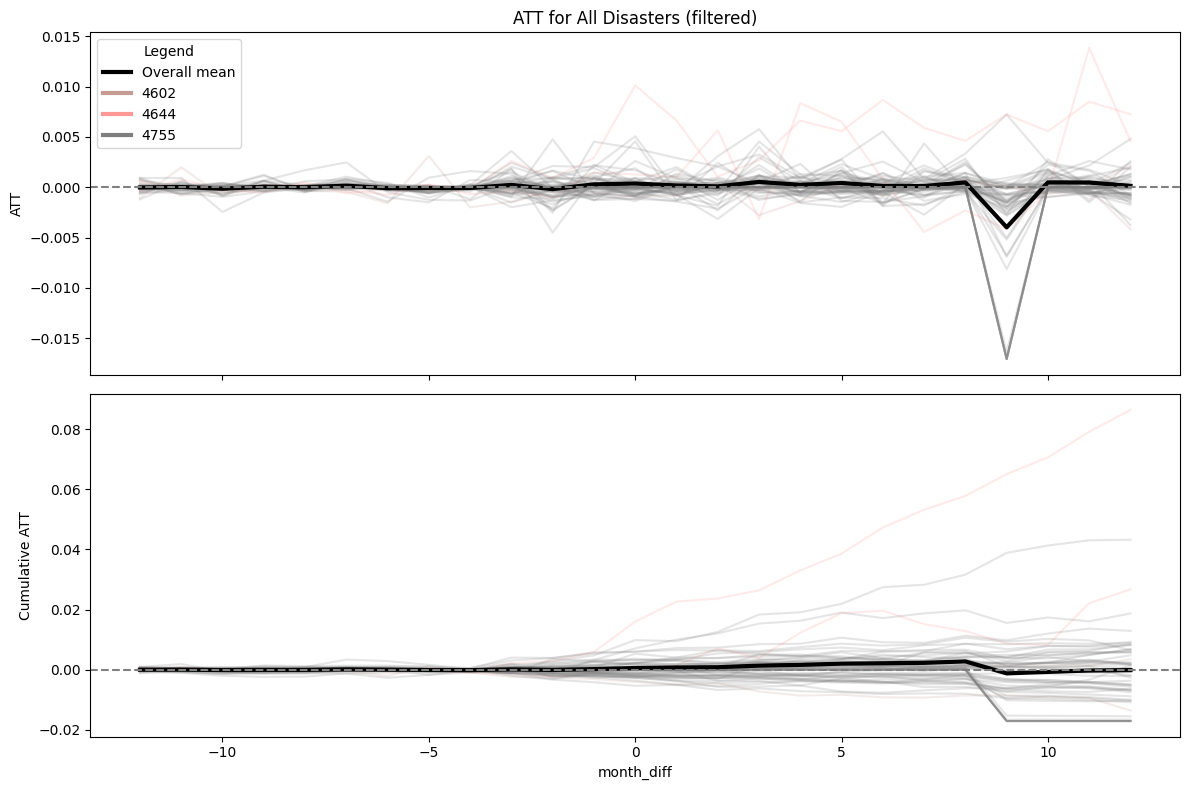

Filtered GEOIDs: ['23803', '23834', '23112', '23113', '10466', '10471', '10550', '10704', '10705', '10803', '11001', '11003', '11004', '11005', '11020', '11040', '11201', '11203', '11204', '11205', '11206', '11207', '11208', '11209', '11211', '11212', '11213', '11214', '11215', '11216', '11217', '11218', '11219', '11220', '11221', '11223', '11224', '11225', '11226', '11228', '11229', '11230', '11231', '11232', '11233', '11234', '11235', '11236', '11237', '11238', '11249', '11414', '11416', '11417', '11421', '11422', '11559', '11580', '11691']


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

att_df = pd.read_csv("/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/att_all_zip_PL.csv")
cum_att_df = pd.read_csv("/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/cum_att_all_zip_PL.csv")

# --- att_all -> DataFrame ---
att_all = {}
for (disaster_id, geo), group in att_df.groupby(["disaster_id", "GEOID"]):
    series = pd.Series(data=group["ATT"].values, index=group["month_diff"].values)
    key = f"{disaster_id}_{geo}"
    att_all[key] = series

# --- cum_att_all -> DataFrame ---
cum_att_all = {}
for (disaster_id, geo), group in cum_att_df.groupby(["disaster_id", "GEOID"]):
    series = pd.Series(data=group["Cumulative_ATT"].values, index=group["month_diff"].values)
    key = f"{disaster_id}_{geo}"
    cum_att_all[key] = series


# --- Disaster list and colors ---
n_disasters = len(disaster_list)
cmap = plt.get_cmap('tab20')
colors = {disaster_list[i]: cmap(i / n_disasters) for i in range(n_disasters)}

# List to store GEOIDs that remain after filtering
filtered_geoids = []

# List to store all filtered ATT/Cumulative ATT series
all_att_series = []
all_cum_att_series = []

fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
legend_plots = {}

# --- value at t = -1 ---
cum_minus1 = []
for key, series in cum_att_all.items():
    if -4 in series.index:
        cum_minus1.append(series.loc[-4])

cum_minus1 = np.array(cum_minus1)

# --- IQR ---
Q1 = np.quantile(cum_minus1, 0.25)
Q3 = np.quantile(cum_minus1, 0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

filtered_geoids = []
all_att_series = []
all_cum_att_series = []
legend_plots = {}

for key, cum_series in cum_att_all.items():
    if -4 in cum_series.index:
        value_minus1 = cum_series.loc[-4]
        if lower <= value_minus1 <= upper:
            disaster_id, geo = key.split('_')
            color = colors.get(disaster_id, 'gray')

            # Plot individual GEOID lines
            axs[0].plot(att_all[key].index, att_all[key], alpha=0.2, color=color)
            axs[1].plot(cum_series.index, cum_series, alpha=0.2, color=color)

            # Add to filtered GEOID list
            filtered_geoids.append(geo)

            # Store for overall mean
            all_att_series.append(att_all[key])
            all_cum_att_series.append(cum_series)

            # For legend
            if disaster_id not in legend_plots:
                legend_plots[disaster_id] = color

# --- Compute overall mean (all disasters together) ---
if len(all_att_series) > 0:
    mean_att = np.mean([s.values for s in all_att_series], axis=0)
    mean_cum_att = np.mean([s.values for s in all_cum_att_series], axis=0)

    axs[0].plot(all_att_series[0].index, mean_att, color='black', linewidth=3, label='Overall mean')
    axs[1].plot(all_cum_att_series[0].index, mean_cum_att, color='black', linewidth=3, label='Overall mean')

# Add horizontal lines at zero
axs[0].axhline(0, color="gray", linestyle="--")
axs[0].set_ylabel("ATT")
axs[0].set_title("ATT for All Disasters (filtered)")

axs[1].axhline(0, color="gray", linestyle="--")
axs[1].set_xlabel("month_diff")
axs[1].set_ylabel("Cumulative ATT")

# Add legend for disasters and overall mean
for disaster_id, color in legend_plots.items():
    axs[0].plot([], [], color=color, label=disaster_id, linewidth=3)
    axs[1].plot([], [], color=color, label=disaster_id, linewidth=3)

axs[0].legend(title="Legend", fontsize=10)

plt.tight_layout()
plt.show()

print("Filtered GEOIDs:", filtered_geoids)

In [ ]:
# -------------------------------------------------
# IQR
# -------------------------------------------------
filtered_att_all = {}
filtered_cum_att_all = {}

for key, cum_series in cum_att_all.items():
    if -4 in cum_series.index:
        v = cum_series.loc[-4]
        if lower <= v <= upper:
            filtered_att_all[key] = att_all[key]
            filtered_cum_att_all[key] = cum_series

# -------------------------------------------------
# filtered_att_df
# -------------------------------------------------
filtered_att_df = pd.DataFrame(
    {key: series.values for key, series in filtered_att_all.items()}
)

filtered_att_df.insert(
    0,
    "month_diff",
    next(iter(filtered_att_all.values())).index
)

# -------------------------------------------------
# filtered_cum_att_df
# -------------------------------------------------
filtered_cum_att_df = pd.DataFrame(
    {key: series.values for key, series in filtered_cum_att_all.items()}
)

filtered_cum_att_df.insert(
    0,
    "month_diff",
    next(iter(filtered_cum_att_all.values())).index
)

save_dir = "/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/"

filtered_att_df.to_csv(
    save_dir + "filtered_att_all_zip_PL.csv",
    index=False
)

filtered_cum_att_df.to_csv(
    save_dir + "filtered_cum_att_all_zip_PL.csv",
    index=False
)

print("Saved filtered_att_all_zip_PL.csv and filtered_cum_att_all_zip_PL.csv")


Saved filtered_att_all_zip_PL.csv and filtered_cum_att_all_zip_PL.csv


# Plot

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import cvxpy as cp
import seaborn as sns
import matplotlib
import statsmodels.api as sm
import matplotlib.gridspec as gridspec

from sklearn.linear_model import LinearRegression
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import (check_X_y, check_array,check_is_fitted)
from statsmodels.tsa.arima_process import ArmaProcess
from google.colab import files
from google.colab import drive
from matplotlib import pyplot as plt
from cycler import cycler

drive.mount('/mnt/drive', force_remount=True)

Mounted at /mnt/drive


In [ ]:
sc_ct =pd.read_csv("/mnt/drive/MyDrive/Colab_data/SC_ct.csv")
sc_ct['GEOID'] = sc_ct['TRACT'].astype(str).str.zfill(11).str.replace(r"\.0$", "", regex=True)
HD_ct =pd.read_csv("/mnt/drive/MyDrive/Colab_data/HD_ct.csv")
HD_ct = HD_ct.dropna(subset=['TRACT']).copy()
HD_ct['GEOID'] = HD_ct['TRACT'].astype(int).astype(str).str.zfill(11)
acs_ct =pd.read_csv("/mnt/drive/MyDrive/Colab_data/acs_ct.csv")
acs_ct['GEOID'] = acs_ct['GEOID'].astype(str).copy()
sc_zip =pd.read_csv("/mnt/drive/MyDrive/Colab_data/SC.csv")
sc_zip = sc_zip.dropna(subset=['zip']).copy()
sc_zip['GEOID'] = sc_zip['zip'].astype(int).astype(str).str.zfill(5)
HD_zip =pd.read_csv("/mnt/drive/MyDrive/Colab_data/HD_zip.csv")
HD_zip['zipCode'] = HD_zip['zipCode'].astype(str).str.strip()
HD_zip['zipCode_clean'] = HD_zip['zipCode'].str.extract(r'(\d+)', expand=False)
HD_zip = HD_zip.dropna(subset=['zipCode_clean']).copy()
HD_zip['GEOID'] = HD_zip['zipCode_clean'].astype(int).astype(str).str.zfill(5)
acs_zip =pd.read_csv("/mnt/drive/MyDrive/Colab_data/acs_zip.csv")
acs_zip['GEOID'] = acs_zip['GEOID'].astype(int).astype(str).str.zfill(5)

sc_all = pd.concat([sc_ct, sc_zip])
HD_all = pd.concat([HD_ct, HD_zip]).iloc[:, 1:10]
acs_all = pd.concat([acs_ct, acs_zip])

df_1 = (pd.read_csv("/mnt/drive/MyDrive/Colab_data/df_ct_filtered.csv")).rename(columns={"FIPS5": "FIPS"})
df_2 = (pd.read_csv("/mnt/drive/MyDrive/Colab_data/df_zip_filtered.csv"))
df_2['state'] = df_2['FIPS'].astype(str).str[0:2]
df_dis =pd.read_csv("/mnt/drive/MyDrive/Colab_data/Disaster.csv")

geo_city_df = pd.concat([df_1[['GEOID', 'city']], df_2[['GEOID', 'city']]]).drop_duplicates()
geo_city_df['GEOID'] = geo_city_df['GEOID'].astype(str)

## With filter

In [ ]:
# CSV
df_fil_ct = pd.read_csv("/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/filtered_cum_att_all_PL.csv").T.iloc[1:]
df_fil_zip = pd.read_csv("/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/filtered_cum_att_all_zip_PL.csv").T.iloc[1:]
df_combined = pd.concat([df_fil_ct, df_fil_zip])

df_combined = df_combined.reset_index()
df_combined = df_combined.rename(columns={'index': 'disaster_GEOID'})
df_combined[['disasterNumber', 'GEOID']] = df_combined['disaster_GEOID'].str.split('_', expand=True)

df_combined['disasterNumber'] = df_combined['disasterNumber'].astype(str)
df_combined['GEOID'] = df_combined['GEOID'].astype(str)
df_combined = df_combined.drop(columns=['disaster_GEOID'])

df_combined.head()

new_columns = [str(i) for i in range(-12, 13)] + ['disasterNumber'] + ['GEOID']
df_combined.columns = new_columns

geo_city_df = pd.concat([df_1[['GEOID', 'city']], df_2[['GEOID', 'city']]]).drop_duplicates()

df_combined['GEOID'] = df_combined['GEOID'].astype(str)
geo_city_df['GEOID'] = geo_city_df['GEOID'].astype(str)

df_combined_with_city = df_combined.merge(
    geo_city_df,
    on='GEOID',
    how='left'
)

disaster_type_dict = {
    "4755": "Severe Storm (2023)",
    "4729": "Severe Storm (2023/06)",
    "4735": "Severe Storm (2023/07)",
    "4665": "Flood (2022)",
    "4651": "Snowstorm (2022)",
    "4645": "Severe Storm (2022)",
    "4637": "Tornado (2022)",
    "4601": "Tornado (2021)",
    "4594": "Severe Ice Storm (2021)",
    "4751": "Severe Storm (2021)",
    "4734": "Hurricane (2023)",
    "4712": "Severe Storm (2023)",
    "4709": "Flood (2023)",
    "4644": "Severe Storm (2022)",
    "4602": "Severe Ice Storm (2021)"
}
df_combined_with_city["disaster_type"] = df_combined_with_city["disasterNumber"].astype(str).map(disaster_type_dict)


In [ ]:
df_combined_with_city = df_combined_with_city[df_combined_with_city["city"] != "Richmond, VA"].copy()

/tmp/ipython-input-695178576.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(keys))


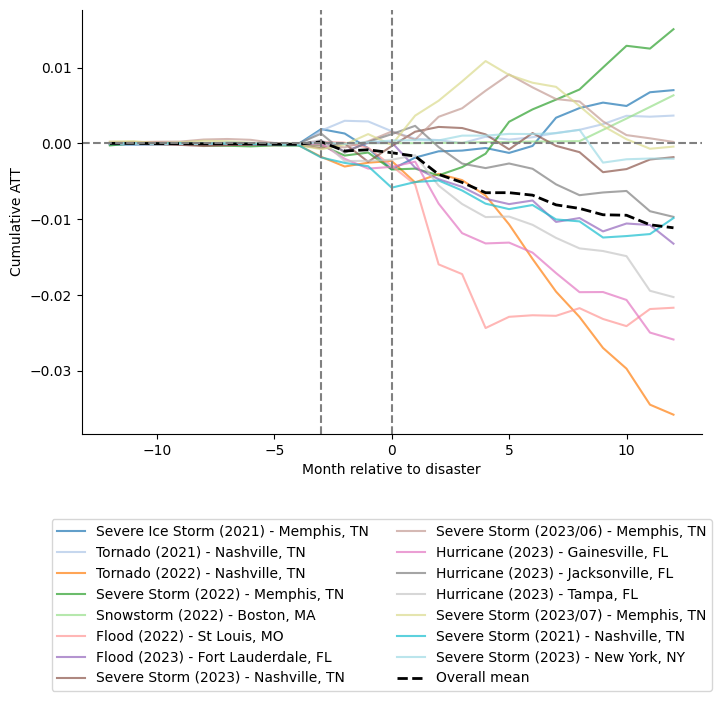

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

month_cols = [str(i) for i in range(-12, 13)]
df_long = df_combined_with_city.melt(
    id_vars=["disasterNumber", "GEOID", "city"],
    value_vars=month_cols,
    var_name="month",
    value_name="cum_att"
)
df_long["month"] = df_long["month"].astype(int)

# --- cum_att_by_city_disaster: (city, disaster) -> list of GEOID series ---
cum_att_by_city_disaster = defaultdict(list)

for (city, disaster, geo), group in df_long.groupby(["city", "disasterNumber", "GEOID"]):
    series = pd.Series(data=group["cum_att"].values, index=group["month"].values)
    cum_att_by_city_disaster[(city, disaster)].append(series)

# --- Function to compute mean across a list of Series ---
def average_series(series_list):
    df = pd.concat(series_list, axis=1)
    return df.mean(axis=1)

# --- Prepare colors ---
keys = sorted(cum_att_by_city_disaster.keys(), key=lambda x: x[1])

colors = cm.get_cmap("tab20", len(keys))
color_dict = {k: colors(i) for i, k in enumerate(keys)}

fig, ax = plt.subplots(figsize=(8, 8))
for key in keys:
    series_list = cum_att_by_city_disaster[key]
    mean_series = average_series(series_list)
    city, disaster_num = key

    # disasterNumber -> disaster_type_dict
    disaster_label = disaster_type_dict.get(str(disaster_num), str(disaster_num))

    label = f"{disaster_label} - {city}"

    # Plot
    ax.plot(mean_series.index, mean_series, label=label, color=color_dict[key], alpha=0.7)

# --- Plot overall mean ---
all_series_list = [s for series_list in cum_att_by_city_disaster.values() for s in series_list]
overall_mean = average_series(all_series_list)
overall_mean = overall_mean.loc[range(-12, 13)]
ax.plot(overall_mean.index, overall_mean, linestyle="--", color="black", linewidth=2, label="Overall mean")

# --- Reference lines ---
ax.axhline(0, ls="--", color="gray")
ax.axvline(-3, ls="--", color="gray")
ax.axvline(0, ls="--", color="gray")

# --- Labels ---
ax.set_xlabel("Month relative to disaster", fontsize=10)
ax.set_ylabel("Cumulative ATT", fontsize=10)

# --- Legend below the plot ---
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.02), ncol=2, fontsize=10)

fig.subplots_adjust(bottom=0.35)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.savefig("figure.png", dpi=200)
plt.show()

from google.colab import files
files.download("figure.png")

/tmp/ipython-input-1724020051.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(keys))


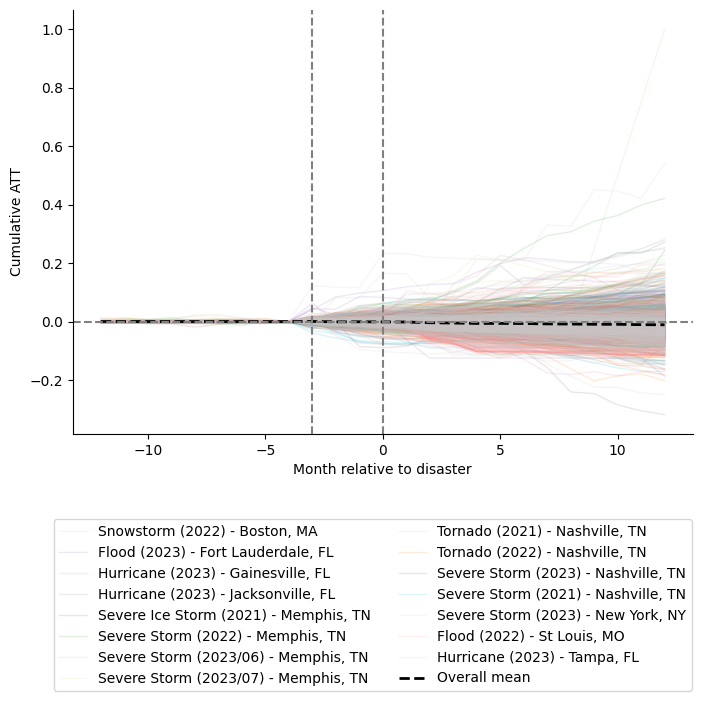

In [ ]:
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

month_cols = [str(i) for i in range(-12, 13)]
df_long = df_combined_with_city.melt(
    id_vars=["disasterNumber", "GEOID", "city"],
    value_vars=month_cols,
    var_name="month",
    value_name="cum_att"
)
df_long["month"] = df_long["month"].astype(int)

# --- cum_att_by_city_disaster: (city, disaster) -> list of GEOID series ---
cum_att_by_city_disaster = defaultdict(list)

for (city, disaster, geo), group in df_long.groupby(["city", "disasterNumber", "GEOID"]):
    series = pd.Series(data=group["cum_att"].values, index=group["month"].values)
    cum_att_by_city_disaster[(city, disaster)].append(series)

# --- Function to compute mean across a list of Series ---
def average_series(series_list):
    df = pd.concat(series_list, axis=1)
    return df.mean(axis=1)

# --- Prepare colors ---
keys = sorted(cum_att_by_city_disaster.keys(), key=lambda x: x[1])

colors = cm.get_cmap("tab20", len(keys))
color_dict = {k: colors(i) for i, k in enumerate(keys)}

fig, ax = plt.subplots(figsize=(8, 8))

for (city, disaster_num), series_list in cum_att_by_city_disaster.items():

    # disasterNumber -> label
    disaster_label = disaster_type_dict.get(str(disaster_num), str(disaster_num))
    label = f"{disaster_label} - {city}"

    for i, s in enumerate(series_list):
        show_label = label if i == 0 else None

        ax.plot(
            s.index,
            s.values,
            color=color_dict[(city, disaster_num)],
            alpha=0.15,
            linewidth=1,
            label=show_label
        )

# --- Plot overall mean ---
all_series_list = [s for series_list in cum_att_by_city_disaster.values() for s in series_list]
overall_mean = average_series(all_series_list)
overall_mean = overall_mean.loc[range(-12, 13)]
ax.plot(overall_mean.index, overall_mean, linestyle="--", color="black", linewidth=2, label="Overall mean")

# --- Reference lines ---
ax.axhline(0, ls="--", color="gray")
ax.axvline(-3, ls="--", color="gray")
ax.axvline(0, ls="--", color="gray")

# --- Labels ---
ax.set_xlabel("Month relative to disaster", fontsize=10)
ax.set_ylabel("Cumulative ATT", fontsize=10)

# --- Legend below the plot ---
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.02), ncol=2, fontsize=10)

fig.subplots_adjust(bottom=0.35)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()


## Without filter

In [ ]:
df_ct = pd.read_csv("/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/cum_att_all_PL.csv")
df_zip = pd.read_csv("/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/cum_att_all_zip_PL.csv")

df_long = pd.concat([df_ct, df_zip], ignore_index=True)

df_long["disaster_id"] = df_long["disaster_id"].astype(str)
df_long["GEOID"] = df_long["GEOID"].astype(str)
df_long["month_diff"] = df_long["month_diff"].astype(int)

geo_city_df = (
    pd.concat([df_1[["GEOID", "city"]], df_2[["GEOID", "city"]]])
    .drop_duplicates()
)

geo_city_df["GEOID"] = geo_city_df["GEOID"].astype(str)

df_long = df_long.merge(
    geo_city_df,
    on="GEOID",
    how="left"
)

disaster_type_dict = {
    "4755": "Severe Storm (2023)",
    "4729": "Severe Storm (2023/06)",
    "4735": "Severe Storm (2023/07)",
    "4665": "Flood (2022)",
    "4651": "Snowstorm (2022)",
    "4645": "Severe Storm (2022)",
    "4637": "Tornado (2022)",
    "4601": "Tornado (2021)",
    "4594": "Severe Ice Storm (2021)",
    "4751": "Severe Storm (2021)",
    "4734": "Hurricane (2023)",
    "4712": "Severe Storm (2023)",
    "4709": "Flood (2023)",
    "4644": "Severe Storm (2022)",
    "4602": "Severe Ice Storm (2021)"
}

df_long["disaster_type"] = df_long["disaster_id"].map(disaster_type_dict)
df_long = df_long[df_long["city"] != "Richmond, VA"].copy()

/tmp/ipython-input-508214826.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(keys))


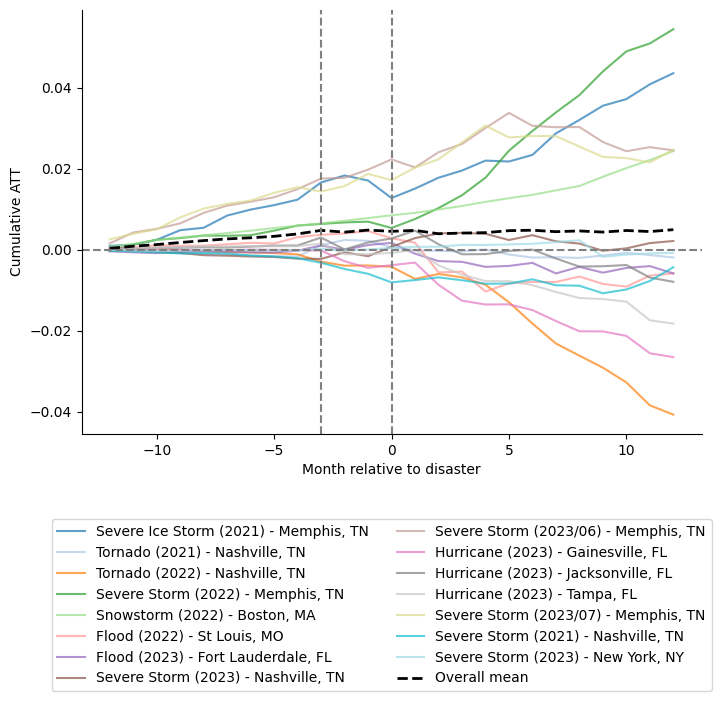

In [ ]:
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

month_cols = [str(i) for i in range(-12, 13)]

df_long["month"] = df_long["month_diff"].astype(int)
df_long["disasterNumber"] = df_long["disaster_id"].astype(int)
df_long["cum_att"] = df_long["Cumulative_ATT"]

# --- cum_att_by_city_disaster: (city, disaster) -> list of GEOID series ---
cum_att_by_city_disaster = defaultdict(list)

for (city, disaster, geo), group in df_long.groupby(["city", "disasterNumber", "GEOID"]):
    series = pd.Series(data=group["cum_att"].values, index=group["month"].values)
    cum_att_by_city_disaster[(city, disaster)].append(series)

# --- Function to compute mean across a list of Series ---
def average_series(series_list):
    df = pd.concat(series_list, axis=1)
    return df.mean(axis=1)

# --- Prepare colors ---
keys = sorted(cum_att_by_city_disaster.keys(), key=lambda x: x[1])

colors = cm.get_cmap("tab20", len(keys))
color_dict = {k: colors(i) for i, k in enumerate(keys)}

fig, ax = plt.subplots(figsize=(8, 8))
for key in keys:
    series_list = cum_att_by_city_disaster[key]
    mean_series = average_series(series_list)
    city, disaster_num = key

    # disasterNumber -> disaster_type_dict
    disaster_label = disaster_type_dict.get(str(disaster_num), str(disaster_num))

    label = f"{disaster_label} - {city}"

    ax.plot(mean_series.index, mean_series, label=label, color=color_dict[key], alpha=0.7)

# --- Plot overall mean ---
all_series_list = [s for series_list in cum_att_by_city_disaster.values() for s in series_list]
overall_mean = average_series(all_series_list)
overall_mean = overall_mean.loc[range(-12, 13)]
ax.plot(overall_mean.index, overall_mean, linestyle="--", color="black", linewidth=2, label="Overall mean")

# --- Reference lines ---
ax.axhline(0, ls="--", color="gray")
ax.axvline(-3, ls="--", color="gray")
ax.axvline(0, ls="--", color="gray")

# --- Labels ---
ax.set_xlabel("Month relative to disaster", fontsize=10)
ax.set_ylabel("Cumulative ATT", fontsize=10)

# --- Legend below the plot ---
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.02), ncol=2, fontsize=10)

fig.subplots_adjust(bottom=0.35)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()


/tmp/ipython-input-1342575764.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(keys))


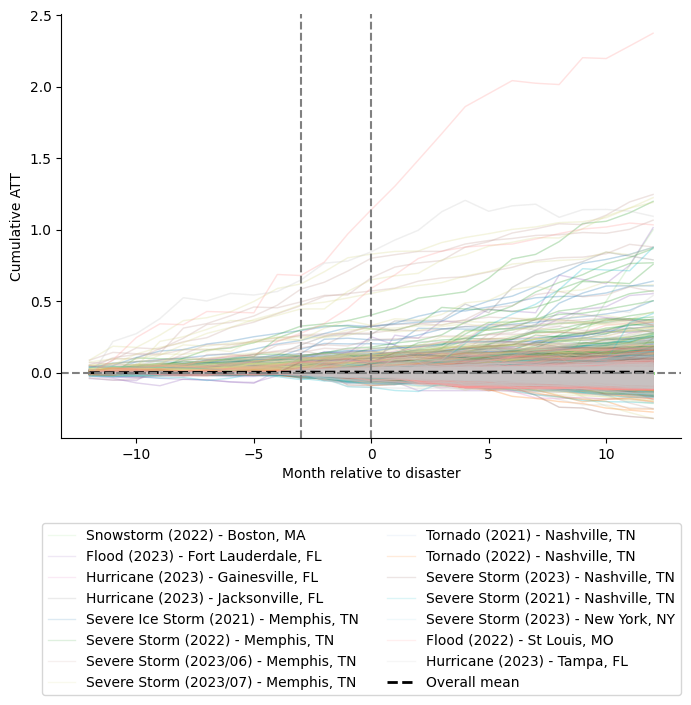

In [ ]:

from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

for (city, disaster, geo), group in df_long.groupby(["city", "disasterNumber", "GEOID"]):
    series = pd.Series(data=group["cum_att"].values, index=group["month"].values)
    cum_att_by_city_disaster[(city, disaster)].append(series)

# --- Function to compute mean across a list of Series ---
def average_series(series_list):
    df = pd.concat(series_list, axis=1)
    return df.mean(axis=1)

# --- Prepare colors ---
keys = sorted(cum_att_by_city_disaster.keys(), key=lambda x: x[1])

colors = cm.get_cmap("tab20", len(keys))
color_dict = {k: colors(i) for i, k in enumerate(keys)}

fig, ax = plt.subplots(figsize=(8, 8))

for (city, disaster_num), series_list in cum_att_by_city_disaster.items():

    disaster_label = disaster_type_dict.get(str(disaster_num), str(disaster_num))
    label = f"{disaster_label} - {city}"

    for i, s in enumerate(series_list):
        show_label = label if i == 0 else None

        ax.plot(
            s.index,
            s.values,
            color=color_dict[(city, disaster_num)],
            alpha=0.15,
            linewidth=1,
            label=show_label
        )

# --- Plot overall mean ---
all_series_list = [s for series_list in cum_att_by_city_disaster.values() for s in series_list]
overall_mean = average_series(all_series_list)
overall_mean = overall_mean.loc[range(-12, 13)]
ax.plot(overall_mean.index, overall_mean, linestyle="--", color="black", linewidth=2, label="Overall mean")

# --- Reference lines ---
ax.axhline(0, ls="--", color="gray")
ax.axvline(-3, ls="--", color="gray")
ax.axvline(0, ls="--", color="gray")

# --- Labels ---
ax.set_xlabel("Month relative to disaster", fontsize=10)
ax.set_ylabel("Cumulative ATT", fontsize=10)

# --- Legend below the plot ---
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.02), ncol=2, fontsize=10)

fig.subplots_adjust(bottom=0.35)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()


## Comparing real and placebo

### Filtered

In [ ]:
# CSV
df_fil_ct = pd.read_csv("/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/filtered_cum_att_all.csv").T.iloc[1:]
df_fil_zip = pd.read_csv("/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/filtered_cum_att_all_zip.csv").T.iloc[1:]
df_combined = pd.concat([df_fil_ct, df_fil_zip])
df_fil_ct_PL = pd.read_csv("/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/filtered_cum_att_all_PL.csv").T.iloc[1:]
df_fil_zip_PL = pd.read_csv("/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/filtered_cum_att_all_zip_PL.csv").T.iloc[1:]
df_combined_PL = pd.concat([df_fil_ct_PL, df_fil_zip_PL])

df_combined = df_combined.reset_index()
df_combined = df_combined.rename(columns={'index': 'disaster_GEOID'})
df_combined[['disasterNumber', 'GEOID']] = df_combined['disaster_GEOID'].str.split('_', expand=True)
df_combined['disasterNumber'] = df_combined['disasterNumber'].astype(str)
df_combined['GEOID'] = df_combined['GEOID'].astype(str)
df_combined = df_combined.drop(columns=['disaster_GEOID'])

df_combined_PL = df_combined_PL.reset_index()
df_combined_PL = df_combined_PL.rename(columns={'index': 'disaster_GEOID'})
df_combined_PL[['disasterNumber', 'GEOID']] = df_combined_PL['disaster_GEOID'].str.split('_', expand=True)
df_combined_PL['disasterNumber'] = df_combined_PL['disasterNumber'].astype(str)
df_combined_PL['GEOID'] = df_combined_PL['GEOID'].astype(str)
df_combined_PL = df_combined_PL.drop(columns=['disaster_GEOID'])

new_columns = [str(i) for i in range(-12, 13)] + ['disasterNumber'] + ['GEOID']   # -12〜12
df_combined.columns = new_columns
df_combined_PL.columns = new_columns

geo_city_df = pd.concat([df_1[['GEOID', 'city']], df_2[['GEOID', 'city']]]).drop_duplicates()

df_combined['GEOID'] = df_combined['GEOID'].astype(str)
df_combined_PL['GEOID'] = df_combined_PL['GEOID'].astype(str)
geo_city_df['GEOID'] = geo_city_df['GEOID'].astype(str)

df_combined_with_city = df_combined.merge(
    geo_city_df,
    on='GEOID',
    how='left'
)

disaster_type_dict = {
    "4755": "Severe Storm (2023)",
    "4729": "Severe Storm (2023/06)",
    "4735": "Severe Storm (2023/07)",
    "4665": "Flood (2022)",
    "4651": "Snowstorm (2022)",
    "4645": "Severe Storm (2022)",
    "4637": "Tornado (2022)",
    "4601": "Tornado (2021)",
    "4594": "Severe Ice Storm (2021)",
    "4751": "Severe Storm (2021)",
    "4734": "Hurricane (2023)",
    "4712": "Severe Storm (2023)",
    "4709": "Flood (2023)",
    "4644": "Severe Storm (2022)",
    "4602": "Severe Ice Storm (2021)"
}

df_combined_with_city["disaster_type"] = df_combined_with_city["disasterNumber"].astype(str).map(disaster_type_dict)


In [ ]:
df_combined_with_city = df_combined_with_city[df_combined_with_city["city"] != "Richmond, VA"].copy()

### Frequency

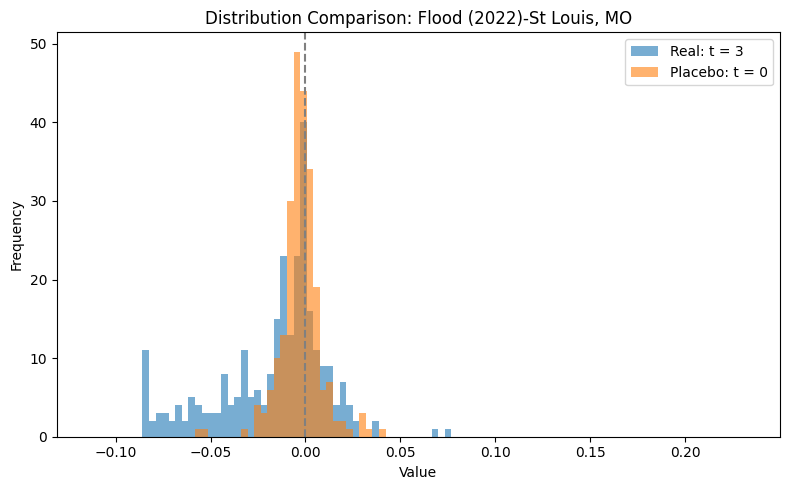

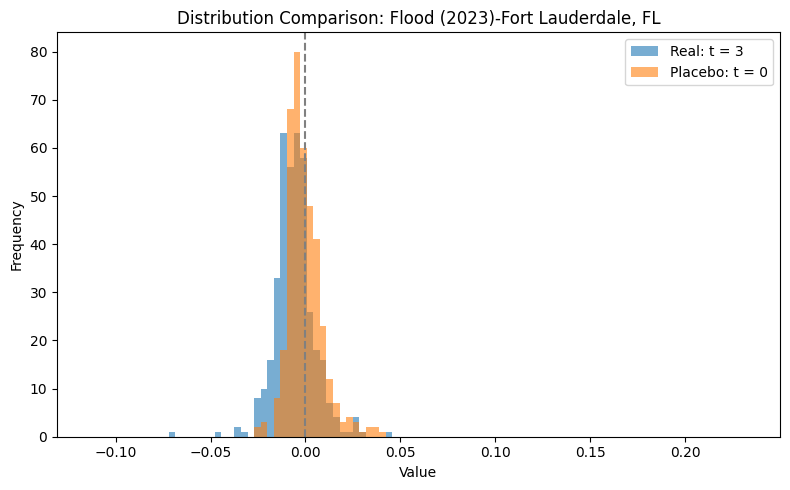

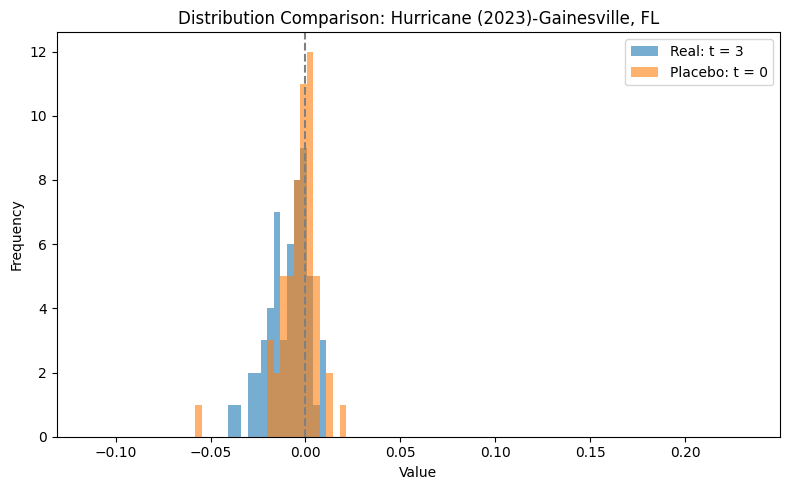

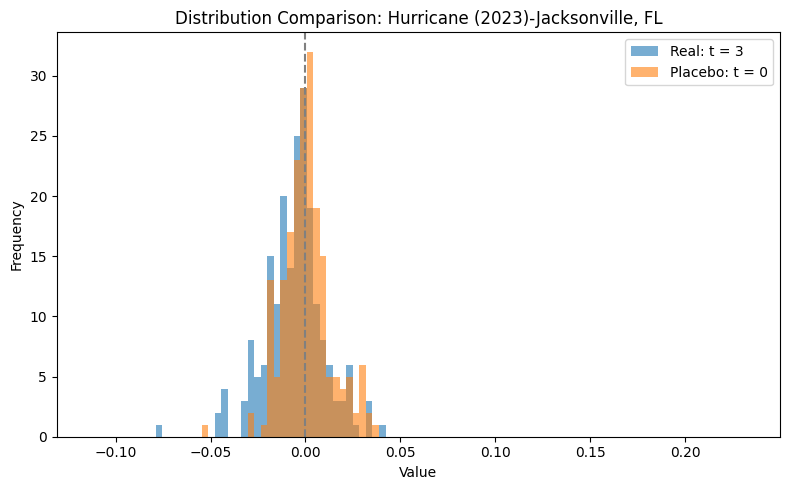

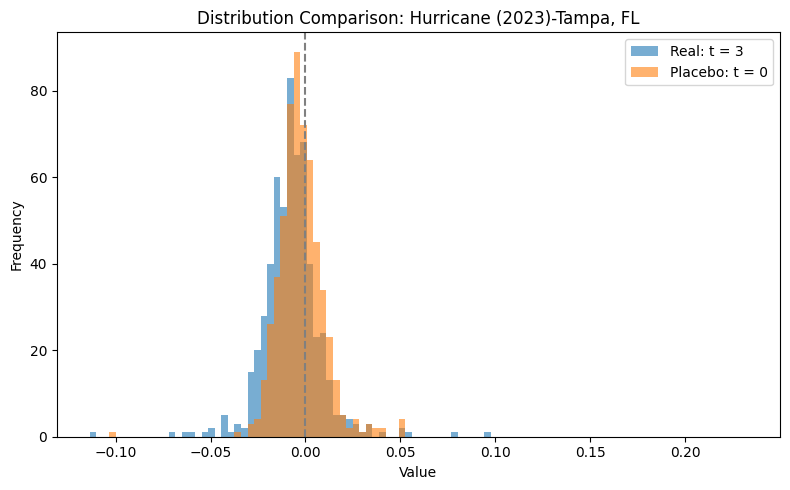

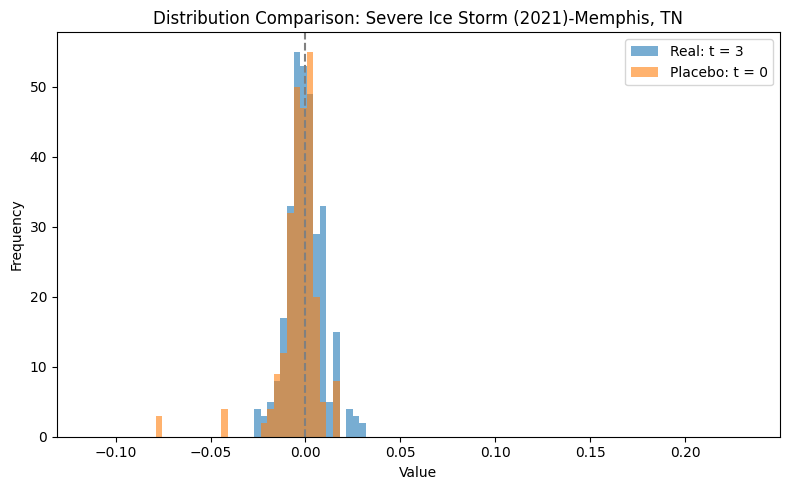

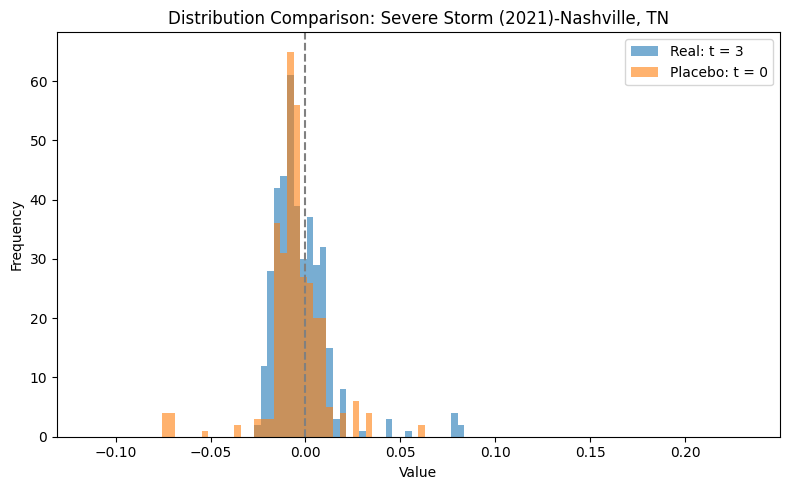

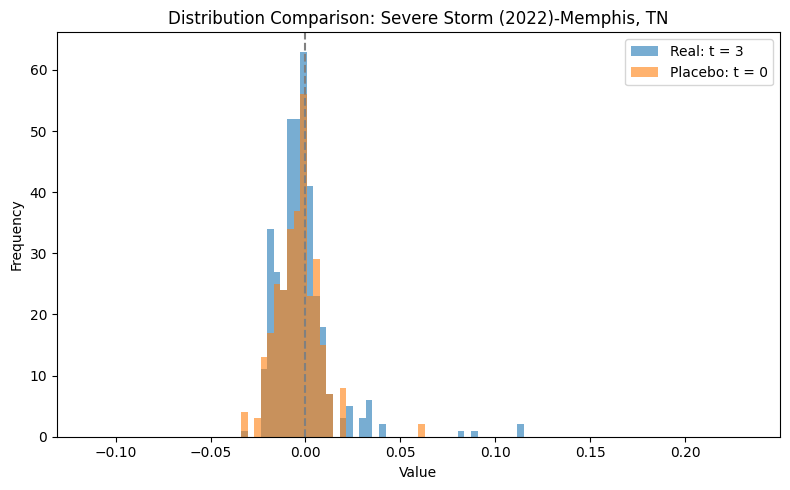

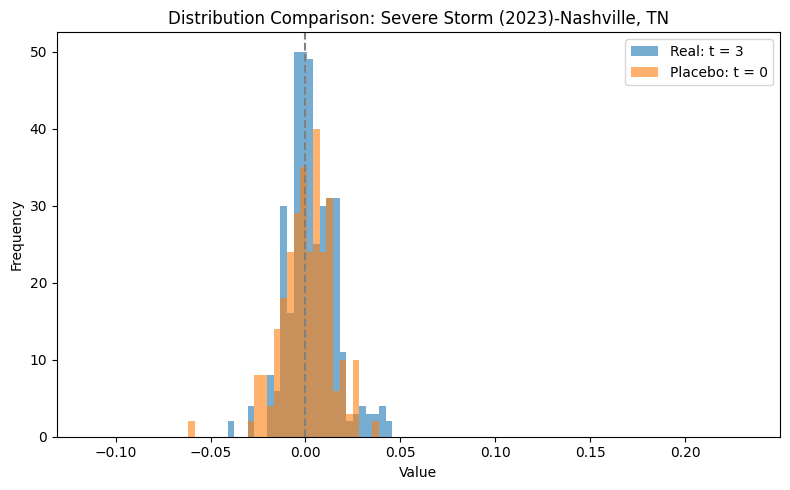

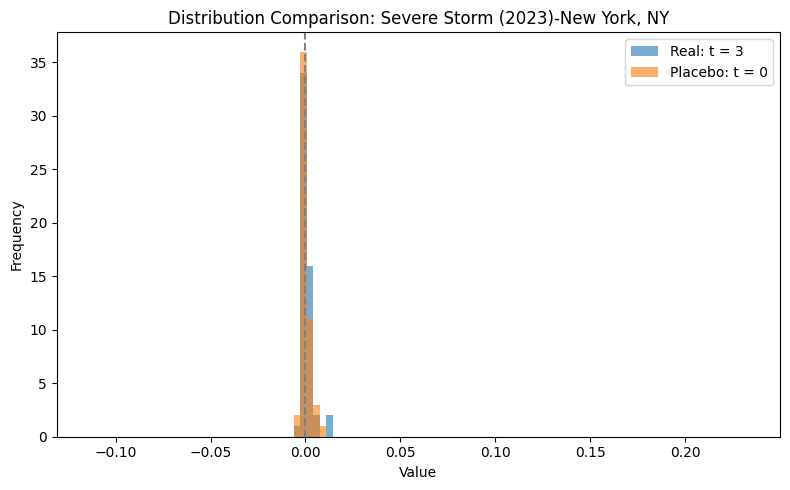

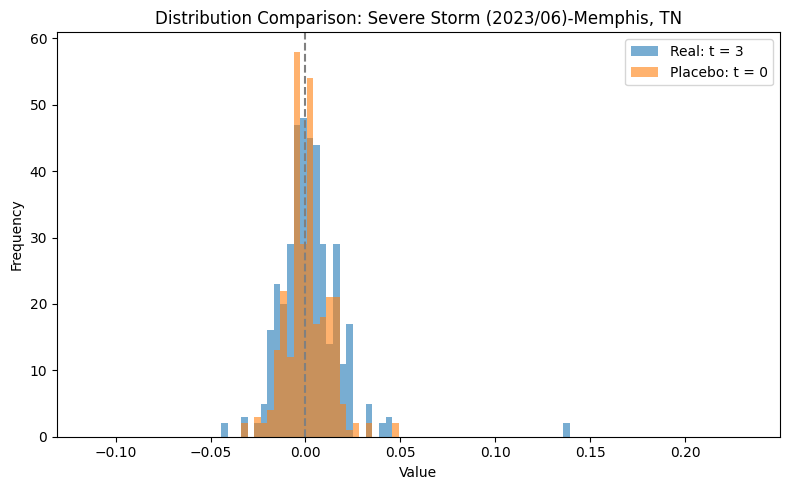

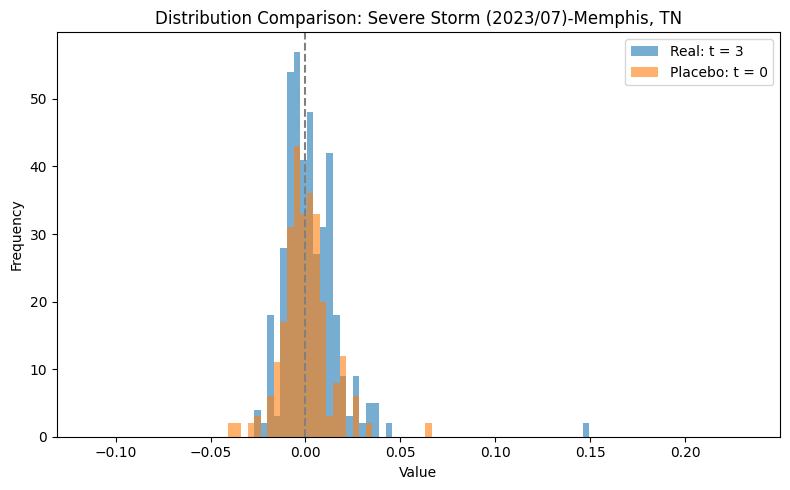

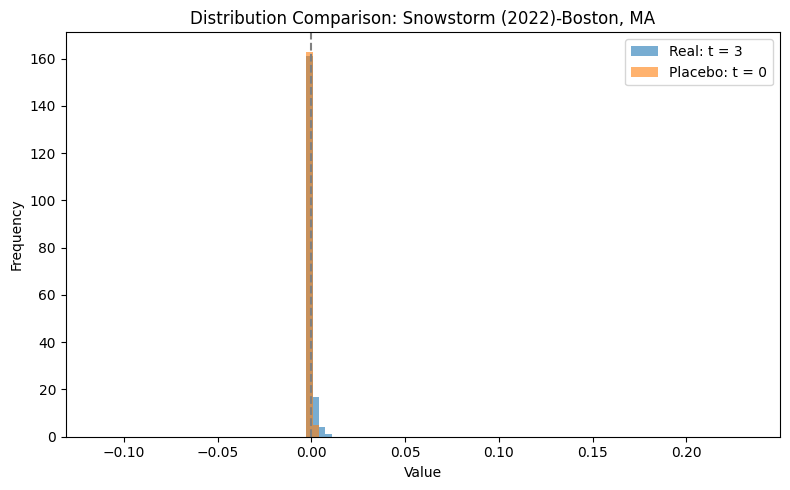

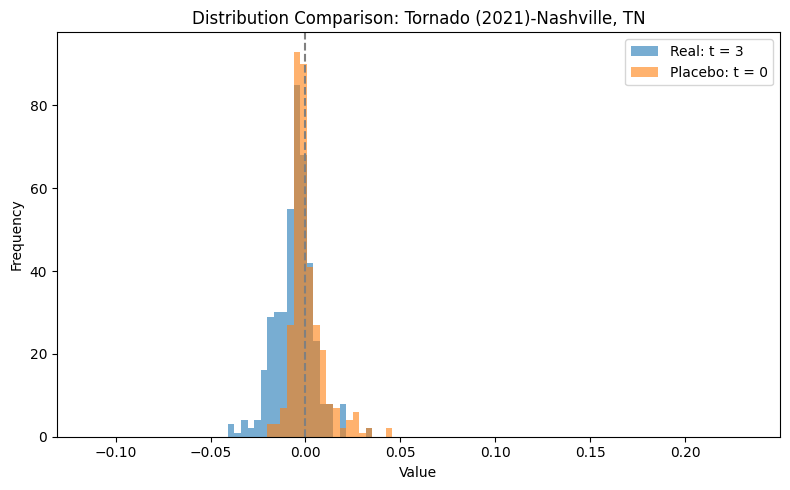

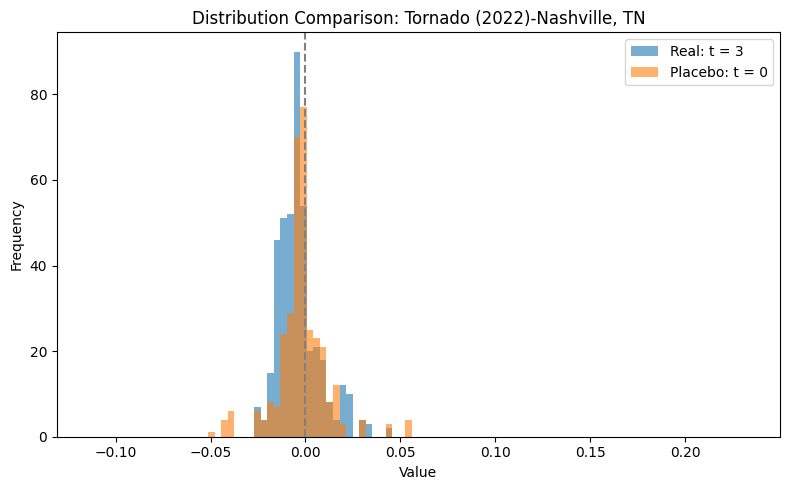

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

df_real = df_combined.merge(df_combined_with_city[["GEOID","city"]], on="GEOID", how="left")
df_placebo = df_combined_PL.merge(df_combined_with_city[["GEOID","city"]], on="GEOID", how="left")

df_real["disaster_type"] = df_real["disasterNumber"].map(disaster_type_dict)
df_placebo["disaster_type"] = df_placebo["disasterNumber"].map(disaster_type_dict)

df_real["label"] = df_real["disaster_type"] + "-" + df_real["city"]
df_placebo["label"] = df_placebo["disaster_type"] + "-" + df_placebo["city"]

all_values = np.concatenate([df_real["3"].dropna().values, df_placebo["0"].dropna().values])
bins = np.histogram_bin_edges(all_values, bins=100)

for label in sorted(set(df_real["label"].dropna()) & set(df_placebo["label"].dropna())):
    real_vals = df_real.loc[df_real["label"] == label, "3"].dropna()
    pl_vals = df_placebo.loc[df_placebo["label"] == label, "0"].dropna()
    if len(real_vals) == 0 or len(pl_vals) == 0: continue
    plt.figure(figsize=(8,5))
    plt.hist(real_vals, bins=bins, alpha=0.6, label="Real: t = 3")
    plt.hist(pl_vals, bins=bins, alpha=0.6, label="Placebo: t = 0")
    plt.axvline(0, color="gray", linestyle="--")
    plt.xlabel("Value"); plt.ylabel("Frequency")
    plt.title(f"Distribution Comparison: {label}")
    plt.legend(); plt.tight_layout(); plt.show()


### Ratio

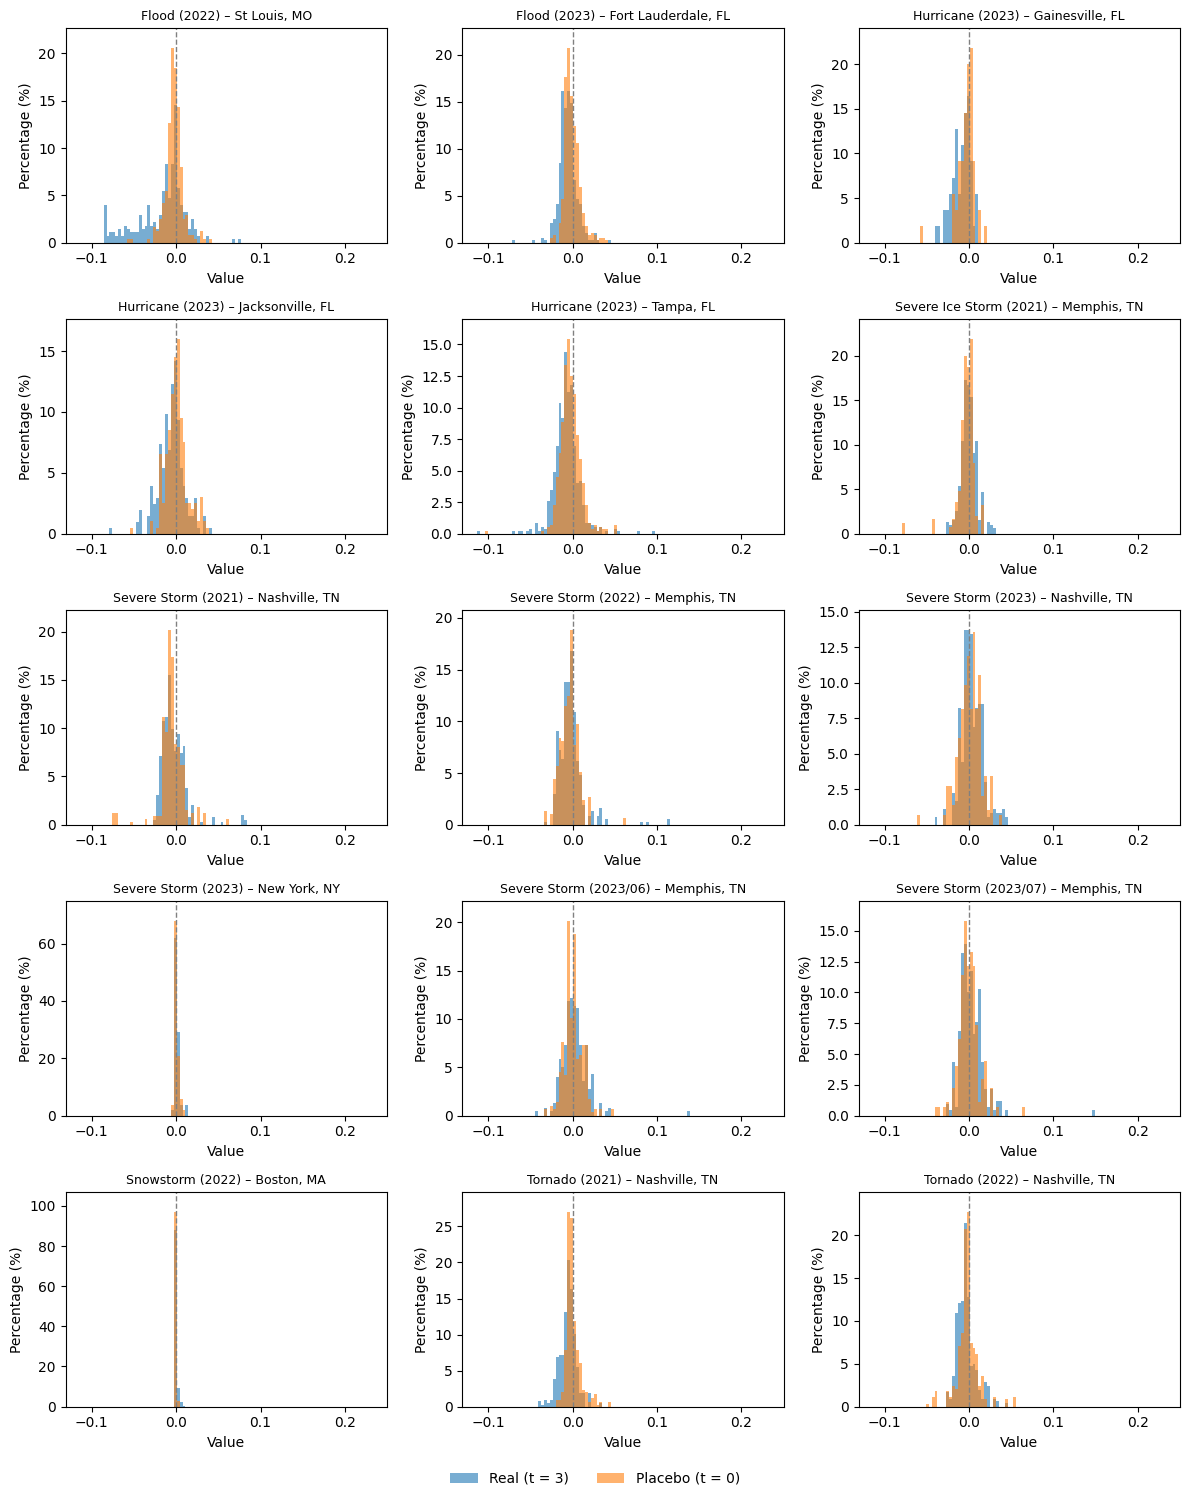

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import math



# ===============================
# 1. Merge city information
# ===============================
df_real = df_combined.merge(
    df_combined_with_city[["GEOID", "city"]],
    on="GEOID",
    how="left"
)

df_placebo = df_combined_PL.merge(
    df_combined_with_city[["GEOID", "city"]],
    on="GEOID",
    how="left"
)

# Map disaster types
df_real["disaster_type"] = df_real["disasterNumber"].map(disaster_type_dict)
df_placebo["disaster_type"] = df_placebo["disasterNumber"].map(disaster_type_dict)

# Create labels
df_real["label"] = df_real["disaster_type"] + " – " + df_real["city"]
df_placebo["label"] = df_placebo["disaster_type"] + " – " + df_placebo["city"]

df_real = df_real[df_real["city"] != "Richmond, VA"].copy()
df_placebo = df_placebo[df_placebo["city"] != "Richmond, VA"].copy()

# ===============================
# 2. Valid labels (exist in both & non-empty)
# ===============================
labels = sorted(
    set(df_real["label"].dropna()) &
    set(df_placebo["label"].dropna())
)

labels = [
    l for l in labels
    if not df_real.loc[df_real["label"] == l, "3"].dropna().empty
    and not df_placebo.loc[df_placebo["label"] == l, "0"].dropna().empty
]

# ===============================
# 3. Common histogram bins
# ===============================
all_values = np.concatenate([
    df_real["3"].dropna().values,
    df_placebo["0"].dropna().values
])

bins = np.histogram_bin_edges(all_values, bins=100)

# ===============================
# 4. Subplot layout (2 columns)
# ===============================
n = len(labels)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(4 * ncols, 3 * nrows),
    sharex=False,
    sharey=False
)

axes = axes.flatten()

# ===============================
# 5. Plot percentage histograms
# ===============================
for i, label in enumerate(labels):
    ax = axes[i]

    real_vals = df_real.loc[df_real["label"] == label, "3"].dropna()
    pl_vals   = df_placebo.loc[df_placebo["label"] == label, "0"].dropna()

    # Percentage weights
    w_real = np.ones(len(real_vals)) / len(real_vals) * 100
    w_pl   = np.ones(len(pl_vals))   / len(pl_vals)   * 100

    # Plot histograms and capture bar heights
    counts_real, _, _ = ax.hist(
        real_vals, bins=bins, weights=w_real, alpha=0.6, label="Real (t = 3)"
    )
    counts_pl, _, _ = ax.hist(
        pl_vals, bins=bins, weights=w_pl, alpha=0.6, label="Placebo (t = 0)"
    )

    ax.axvline(0, color="gray", linestyle="--", linewidth=1)

    # Dynamic y-limit
    ymax = max(counts_real.max(), counts_pl.max())
    ax.set_ylim(0, ymax * 1.1)  # 10% padding

    ax.set_title(label, fontsize=9)
    ax.set_xlabel("Value")
    ax.set_ylabel("Percentage (%)")

# ===============================
# 7. Single legend at bottom
# ===============================
handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    legend_labels,
    loc="lower center",
    ncol=2,
    frameon=False,
    fontsize=10
)

# ===============================
# 8. Final layout
# ===============================
plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.savefig("figure.png", dpi=200)
plt.show()
from google.colab import files
files.download("figure.png")

### All

In [ ]:
df_fil_ct = pd.read_csv("/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/cum_att_all.csv")
df_fil_zip = pd.read_csv("/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/cum_att_all_zip.csv")
df_long = pd.concat([df_ct, df_zip], ignore_index=True)
df_ct = pd.read_csv("/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/cum_att_all_PL.csv")
df_zip = pd.read_csv("/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/cum_att_all_zip_PL.csv")
df_long_PL = pd.concat([df_ct, df_zip], ignore_index=True)

# 型を統一
df_long["disaster_id"] = df_long["disaster_id"].astype(str)
df_long["GEOID"] = df_long["GEOID"].astype(str)
df_long["month_diff"] = df_long["month_diff"].astype(int)
df_long = df_long.merge(geo_city_df,on="GEOID",how="left")
df_long["disaster_type"] = df_long["disaster_id"].map(disaster_type_dict)
df_long["month"] = df_long["month_diff"].astype(int)
df_long["disasterNumber"] = df_long["disaster_id"].astype(int)
df_long["cum_att"] = df_long["Cumulative_ATT"]

df_long_PL["disaster_id"] = df_long_PL["disaster_id"].astype(str)
df_long_PL["GEOID"] = df_long_PL["GEOID"].astype(str)
df_long_PL["month_diff"] = df_long_PL["month_diff"].astype(int)
df_long_PL = df_long_PL.merge(geo_city_df,on="GEOID",how="left")
df_long_PL["disaster_type"] = df_long_PL["disaster_id"].map(disaster_type_dict)
df_long_PL["month"] = df_long_PL["month_diff"].astype(int)
df_long_PL["disasterNumber"] = df_long_PL["disaster_id"].astype(int)
df_long_PL["cum_att"] = df_long_PL["Cumulative_ATT"]


for (city, disaster, geo), group in df_long.groupby(["city", "disasterNumber", "GEOID"]):
    series = pd.Series(data=group["cum_att"].values, index=group["month"].values)
    cum_att_by_city_disaster[(city, disaster)].append(series)

for (city, disaster, geo), group in df_long_PL.groupby(["city", "disasterNumber", "GEOID"]):
    series = pd.Series(data=group["cum_att"].values, index=group["month"].values)
    cum_att_by_city_disaster[(city, disaster)].append(series)

In [ ]:
df_placebo = df_long_PL.pivot_table(
    index=["city", "disasterNumber", "GEOID", "disaster_type"],
    columns="month",
    values="cum_att"
)

df_placebo = df_placebo.sort_index(axis=1)
df_placebo = df_placebo.reset_index()

df_real = df_long.pivot_table(
    index=["city", "disasterNumber", "GEOID", "disaster_type"],
    columns="month",
    values="cum_att"
)

df_real = df_real.sort_index(axis=1)
df_real = df_real.reset_index()

df_placebo.columns = df_placebo.columns.map(str)
df_real.columns = df_real.columns.map(str)

df_real = df_real[df_real["city"] != "Richmond, VA"].copy()
df_placebo = df_placebo[df_placebo["city"] != "Richmond, VA"].copy()


### Frequency

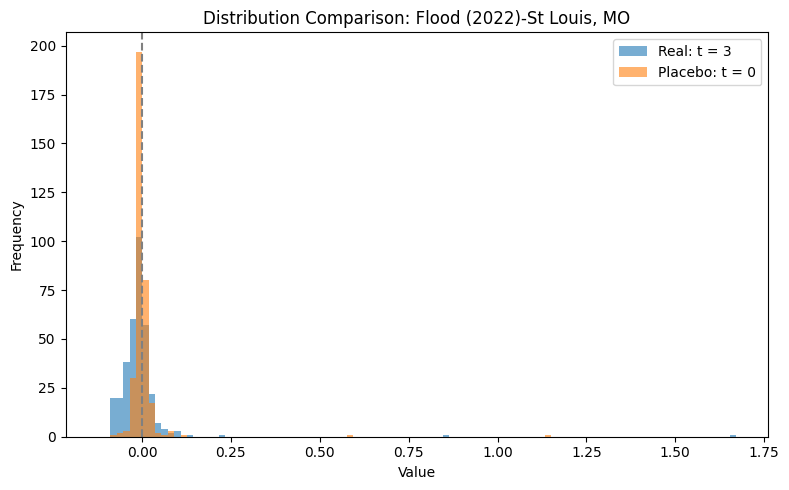

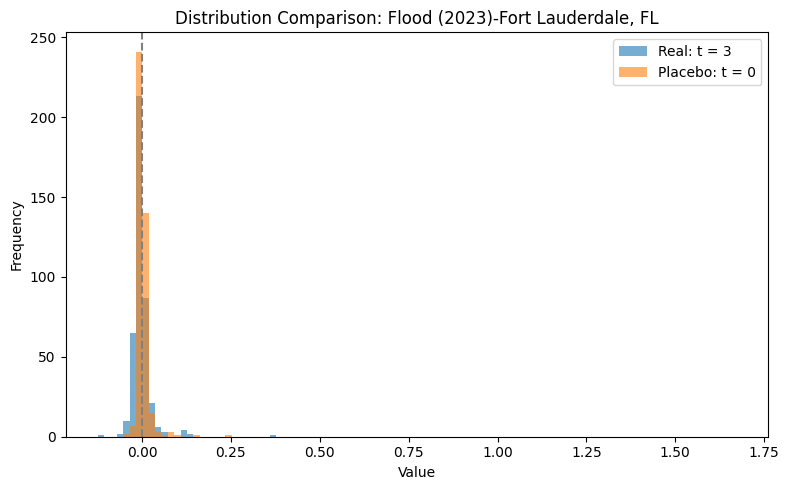

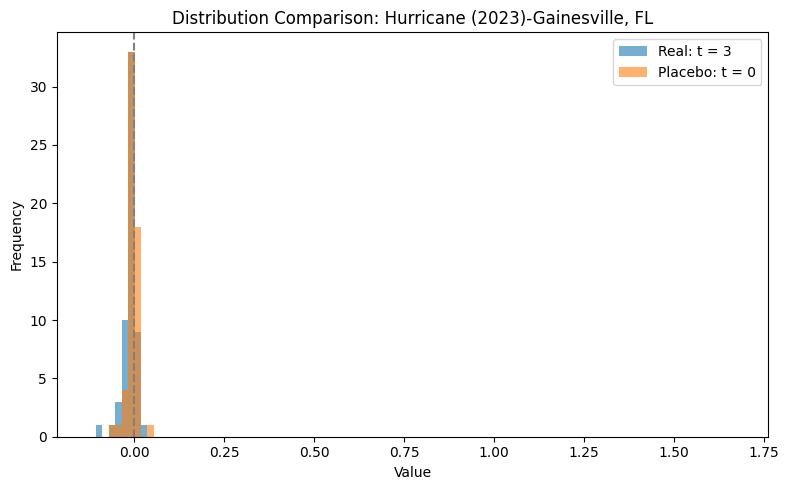

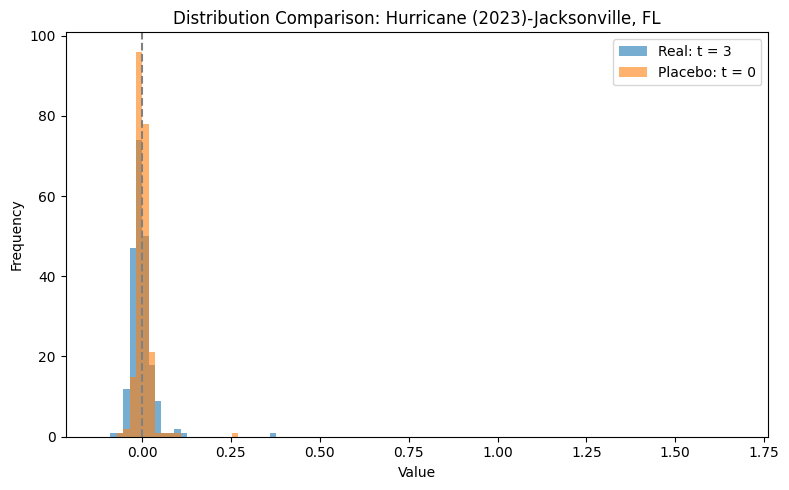

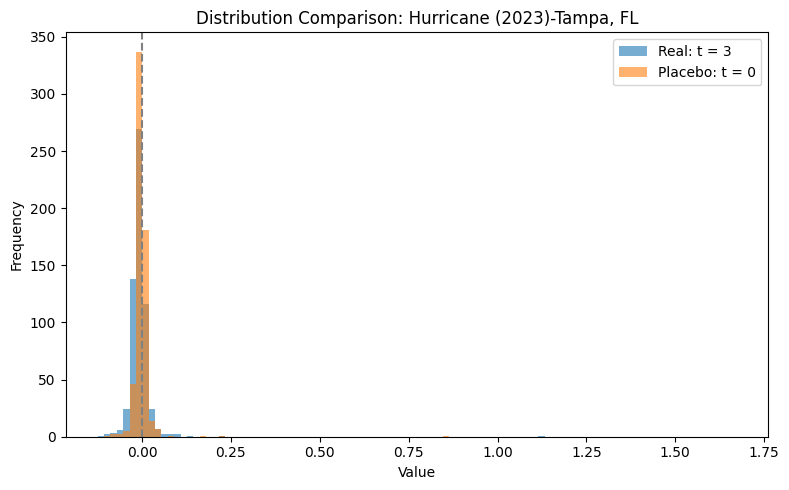

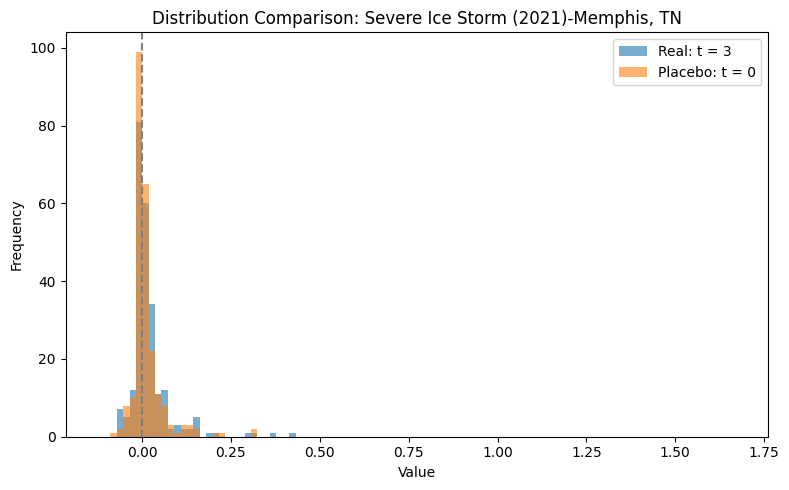

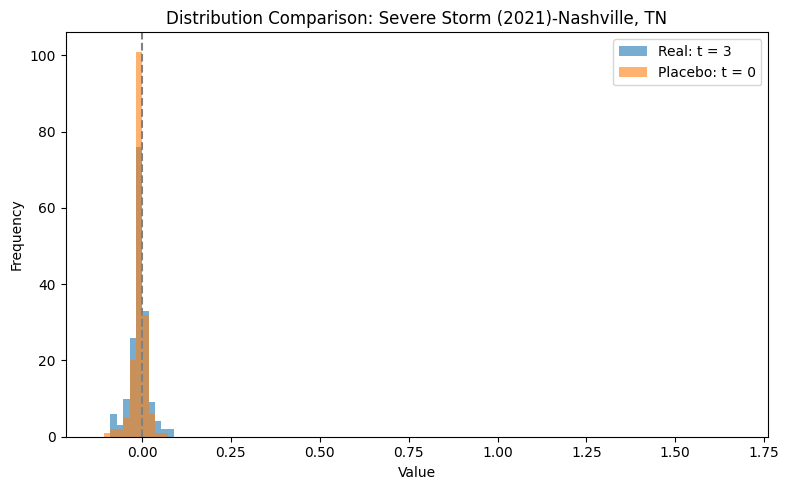

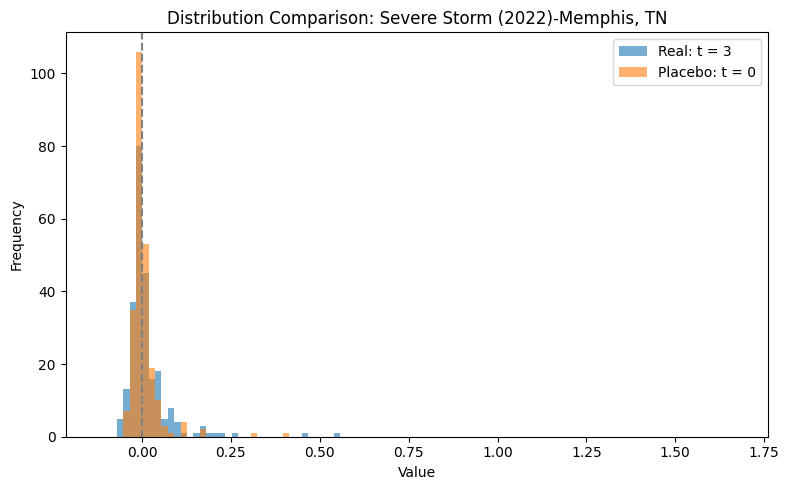

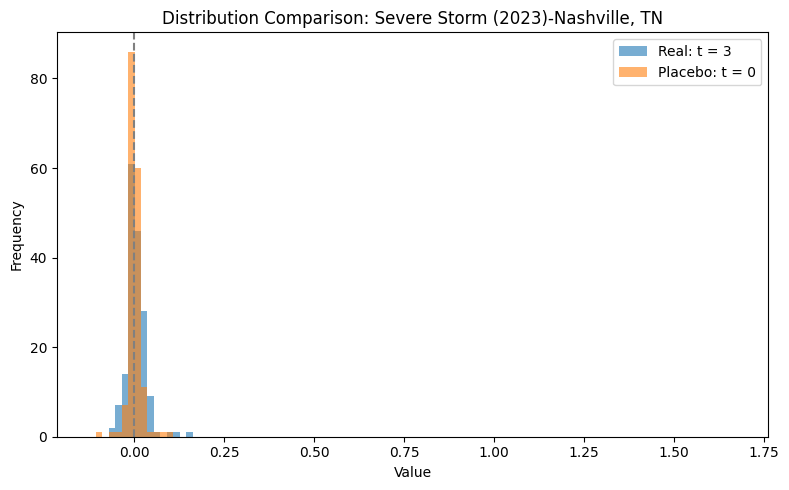

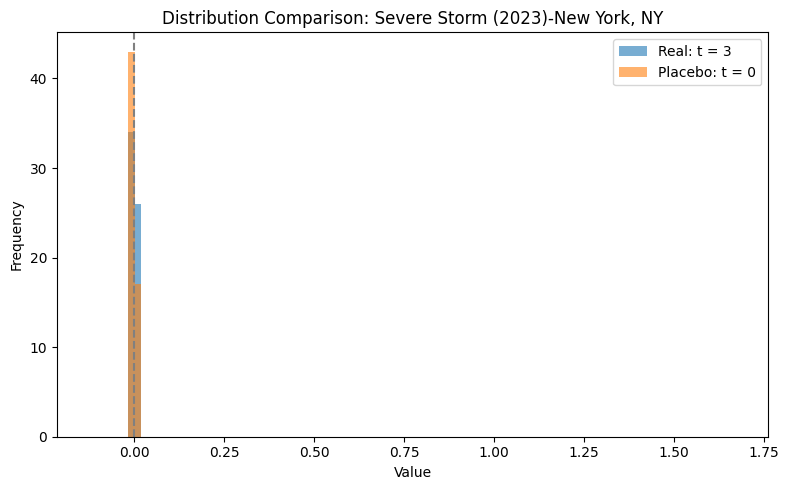

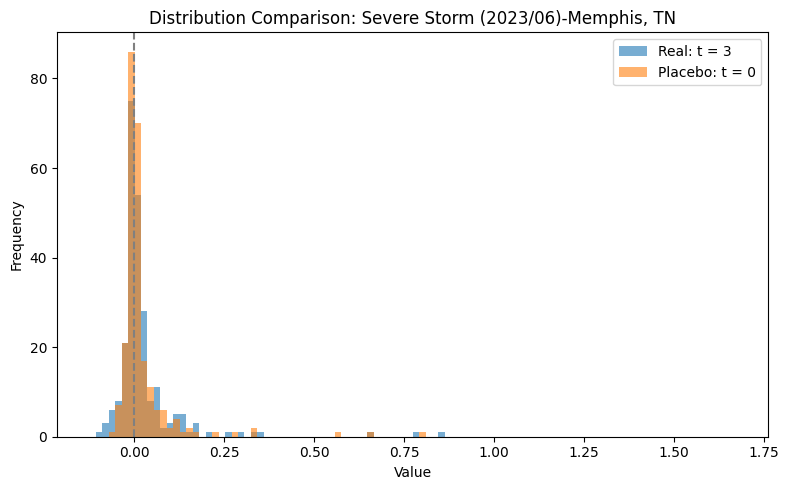

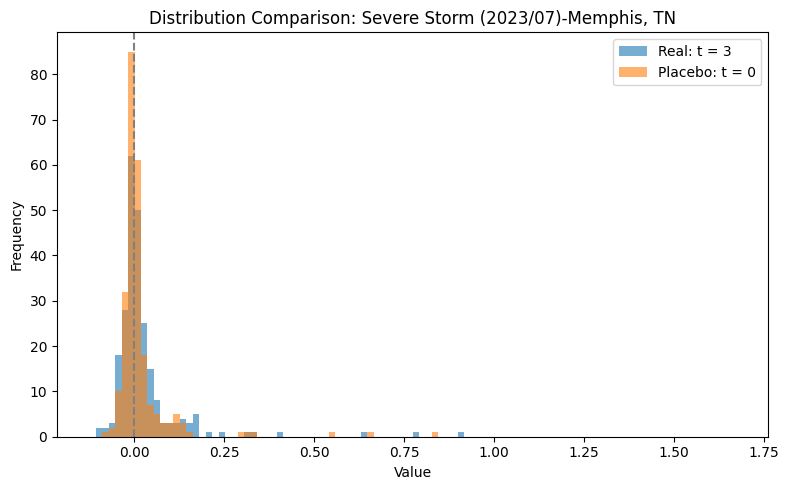

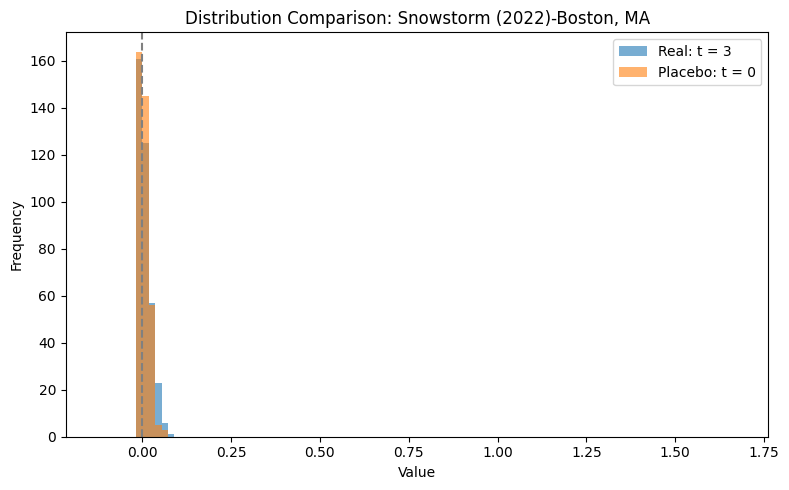

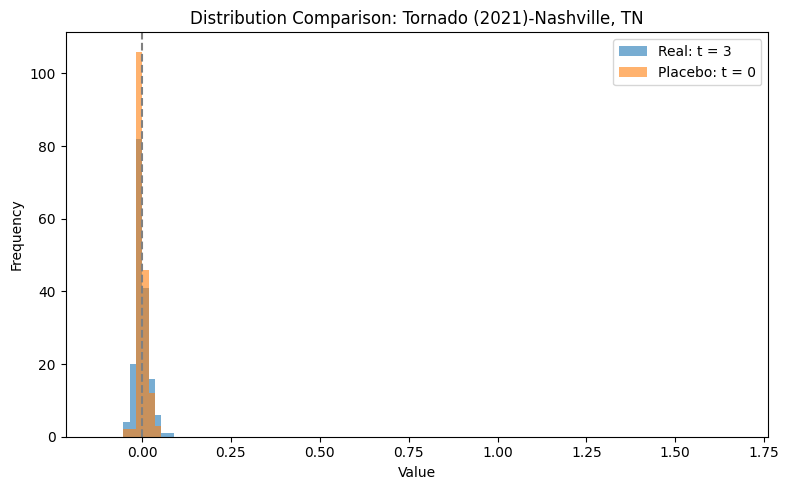

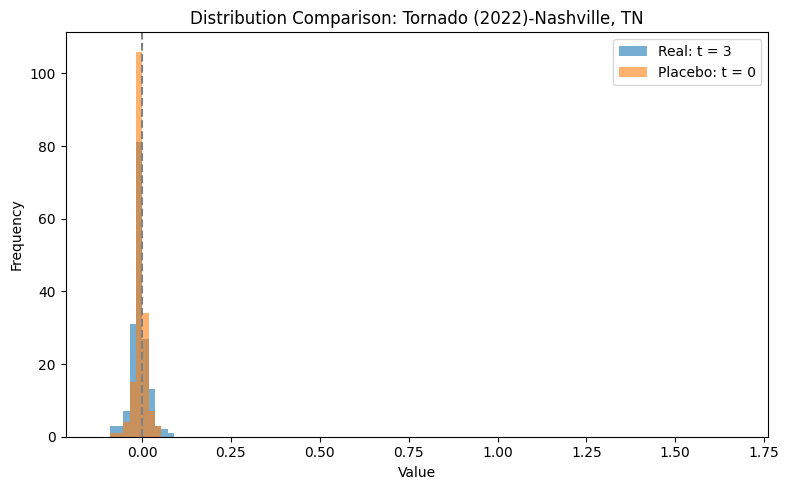

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

df_real["label"] = df_real["disaster_type"] + "-" + df_real["city"]
df_placebo["label"] = df_placebo["disaster_type"] + "-" + df_placebo["city"]

all_values = np.concatenate([df_real["3"].dropna().values, df_placebo["0"].dropna().values])
bins = np.histogram_bin_edges(all_values, bins=100)

for label in sorted(set(df_real["label"].dropna()) & set(df_placebo["label"].dropna())):
    real_vals = df_real.loc[df_real["label"] == label, "3"].dropna()
    pl_vals = df_placebo.loc[df_placebo["label"] == label, "0"].dropna()
    if len(real_vals) == 0 or len(pl_vals) == 0: continue
    plt.figure(figsize=(8,5))
    plt.hist(real_vals, bins=bins, alpha=0.6, label="Real: t = 3")
    plt.hist(pl_vals, bins=bins, alpha=0.6, label="Placebo: t = 0")
    plt.axvline(0, color="gray", linestyle="--")
    plt.xlabel("Value"); plt.ylabel("Frequency")
    plt.title(f"Distribution Comparison: {label}")
    plt.legend(); plt.tight_layout(); plt.show()

### Ratio

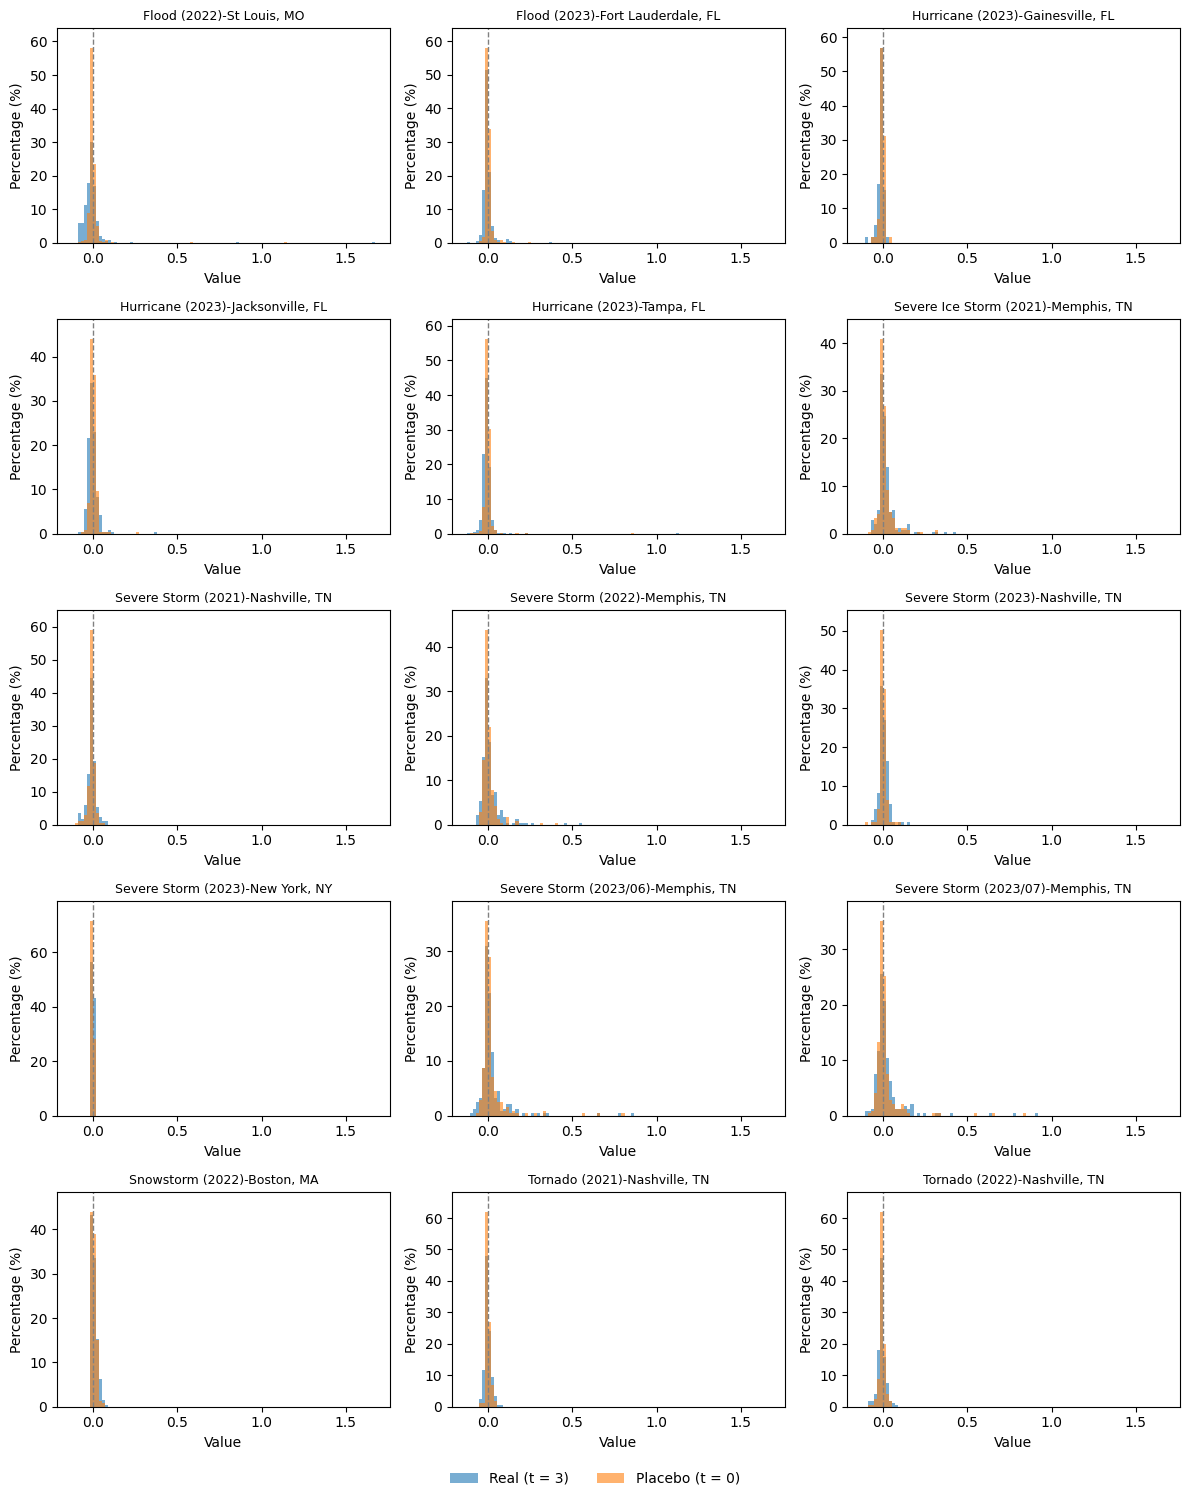

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import math

# ===============================
# 2. Valid labels (exist in both & non-empty)
# ===============================
labels = sorted(
    set(df_real["label"].dropna()) &
    set(df_placebo["label"].dropna())
)

labels = [
    l for l in labels
    if not df_real.loc[df_real["label"] == l, "3"].dropna().empty
    and not df_placebo.loc[df_placebo["label"] == l, "0"].dropna().empty
]

# ===============================
# 3. Common histogram bins
# ===============================
all_values = np.concatenate([
    df_real["3"].dropna().values,
    df_placebo["0"].dropna().values
])

bins = np.histogram_bin_edges(all_values, bins=100)

# ===============================
# 4. Subplot layout (2 columns)
# ===============================
n = len(labels)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(4 * ncols, 3 * nrows),
    sharex=False,
    sharey=False
)

axes = axes.flatten()

# ===============================
# 5. Plot percentage histograms
# ===============================
for i, label in enumerate(labels):
    ax = axes[i]

    real_vals = df_real.loc[df_real["label"] == label, "3"].dropna()
    pl_vals   = df_placebo.loc[df_placebo["label"] == label, "0"].dropna()

    # Percentage weights
    w_real = np.ones(len(real_vals)) / len(real_vals) * 100
    w_pl   = np.ones(len(pl_vals))   / len(pl_vals)   * 100

    # Plot histograms and capture bar heights
    counts_real, _, _ = ax.hist(
        real_vals, bins=bins, weights=w_real, alpha=0.6, label="Real (t = 3)"
    )
    counts_pl, _, _ = ax.hist(
        pl_vals, bins=bins, weights=w_pl, alpha=0.6, label="Placebo (t = 0)"
    )

    ax.axvline(0, color="gray", linestyle="--", linewidth=1)

    # Dynamic y-limit
    ymax = max(counts_real.max(), counts_pl.max())
    ax.set_ylim(0, ymax * 1.1)  # 10% padding

    ax.set_title(label, fontsize=9)
    ax.set_xlabel("Value")
    ax.set_ylabel("Percentage (%)")

# ===============================
# 7. Single legend at bottom
# ===============================
handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    legend_labels,
    loc="lower center",
    ncol=2,
    frameon=False,
    fontsize=10
)

# ===============================
# 8. Final layout
# ===============================
plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.savefig("figure.png", dpi=200)
plt.show()
from google.colab import files
files.download("figure.png")